In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import rankdata
from decimal import Decimal
import itertools
import csv
import seaborn as sns
from scipy.stats import mannwhitneyu
import requests
import re
import ast

In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('hello.png')
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [3]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')
x2foAveALL = csv2dict('../data/assets/xgroup2/xgroup2foAveALL.csv')
print(len(x2foAveNONE))
print(len(x2foAveALL))

397
397


# get

In [4]:
# Example: Retrieve information about the hsa:5116 gene
gene_id = 'hsa:5116'
url = f'https://rest.kegg.jp/get/{gene_id}'

response = requests.get(url)

if response.status_code == 200:
    # Print the content of the response
    print(response.text)
else:
    print(f"Error: {response.status_code}")

ENTRY       5116              CDS       T01001
SYMBOL      PCNT, KEN, MOPD2, PCN, PCNT2, PCNTB, PCTN2, SCKL4
NAME        (RefSeq) pericentrin
ORTHOLOGY   K16481  pericentrin
ORGANISM    hsa  Homo sapiens (human)
DISEASE     H00991  Microcephalic osteodysplastic primordial dwarfism, type II (MOPD II)
BRITE       KEGG Orthology (KO) [BR:hsa00001]
             09180 Brite Hierarchies
              09182 Protein families: genetic information processing
               03036 Chromosome and associated proteins [BR:hsa03036]
                5116 (PCNT)
            Chromosome and associated proteins [BR:hsa03036]
             Eukaryotic type
              Centrosome formation proteins
               Centriole proteins
                5116 (PCNT)
POSITION    21:46324156..46445769
MOTIF       Pfam: PACT_coil_coil
DBLINKS     NCBI-GeneID: 5116
            NCBI-ProteinID: NP_006022
            OMIM: 605925
            HGNC: 16068
            Ensembl: ENSG00000160299
            UniProt: O95613
AASE

# info

In [5]:
url = f'https://rest.kegg.jp/info/pathway'
response = requests.get(url)

if response.status_code == 200:
    # Print the content of the response
    print(response.text)
else:
    print(f"Error: {response.status_code}")

pathway          KEGG Pathway Database
path             Release 109.0+/03-13, Mar 24
                 Kanehisa Laboratories
                 1,142,182 entries

linked db        module
                 ko
                 <org>
                 genome
                 compound
                 glycan
                 reaction
                 rclass
                 enzyme
                 network
                 disease
                 drug
                 pubmed



In [6]:
url = f'https://rest.kegg.jp/info/module'
response = requests.get(url)

if response.status_code == 200:
    # Print the content of the response
    print(response.text)
else:
    print(f"Error: {response.status_code}")

module           KEGG Module Database
md               Release 109.0+/03-13, Mar 24
                 Kanehisa Laboratories
                 561 entries

linked db        pathway
                 ko
                 <org>
                 genome
                 compound
                 glycan
                 reaction
                 enzyme
                 pubmed



# list

In [7]:
url = f'https://rest.kegg.jp/list/module'
response = requests.get(url)

if response.status_code == 200:
    print(response.text)
    modules = {}
    try:
        for line in response.text.split('\n'):
            modules[line.split('\t')[0]] = line.split('\t')[1]
    except IndexError:  # for the last '\n'
        pass
else:
    print(f"Error: {response.status_code}")

M00001	Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate
M00002	Glycolysis, core module involving three-carbon compounds
M00003	Gluconeogenesis, oxaloacetate => fructose-6P
M00004	Pentose phosphate pathway (Pentose phosphate cycle)
M00005	PRPP biosynthesis, ribose 5P => PRPP
M00006	Pentose phosphate pathway, oxidative phase, glucose 6P => ribulose 5P
M00007	Pentose phosphate pathway, non-oxidative phase, fructose 6P => ribose 5P
M00008	Entner-Doudoroff pathway, glucose-6P => glyceraldehyde-3P + pyruvate
M00009	Citrate cycle (TCA cycle, Krebs cycle)
M00010	Citrate cycle, first carbon oxidation, oxaloacetate => 2-oxoglutarate
M00011	Citrate cycle, second carbon oxidation, 2-oxoglutarate => oxaloacetate
M00012	Glyoxylate cycle
M00013	Malonate semialdehyde pathway, propanoyl-CoA => acetyl-CoA
M00014	Glucuronate pathway (uronate pathway)
M00015	Proline biosynthesis, glutamate => proline
M00016	Lysine biosynthesis, succinyl-DAP pathway, aspartate => lysine
M00017	Methionine biosynthe

In [8]:
modules

{'M00001': 'Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate',
 'M00002': 'Glycolysis, core module involving three-carbon compounds',
 'M00003': 'Gluconeogenesis, oxaloacetate => fructose-6P',
 'M00004': 'Pentose phosphate pathway (Pentose phosphate cycle)',
 'M00005': 'PRPP biosynthesis, ribose 5P => PRPP',
 'M00006': 'Pentose phosphate pathway, oxidative phase, glucose 6P => ribulose 5P',
 'M00007': 'Pentose phosphate pathway, non-oxidative phase, fructose 6P => ribose 5P',
 'M00008': 'Entner-Doudoroff pathway, glucose-6P => glyceraldehyde-3P + pyruvate',
 'M00009': 'Citrate cycle (TCA cycle, Krebs cycle)',
 'M00010': 'Citrate cycle, first carbon oxidation, oxaloacetate => 2-oxoglutarate',
 'M00011': 'Citrate cycle, second carbon oxidation, 2-oxoglutarate => oxaloacetate',
 'M00012': 'Glyoxylate cycle',
 'M00013': 'Malonate semialdehyde pathway, propanoyl-CoA => acetyl-CoA',
 'M00014': 'Glucuronate pathway (uronate pathway)',
 'M00015': 'Proline biosynthesis, glutamate => pr

In [9]:
len(modules)  # 479

481

In [10]:
# module2description = modules
# dict2csv(module2description, 'module2description.csv')

# CONV

# LINK

# What does a module look like?

In [11]:
def getModuleInfo(module):
    base_url = 'https://rest.kegg.jp'
    module_id = module
    url = f'{base_url}/get/{module_id}'
    print(requests.get(url).text)

In [12]:
# module with REACTION
getModuleInfo('M00975')

ENTRY       M00975            Pathway   Module
NAME        Betaine degradation, bacteria, betaine => pyruvate
DEFINITION  K00479+K21832 (((K00309,K00315) (K00301,K00302+K00303+K00304+K00305)),K21833+K21834+K25960+K25961) K00600 (K01752,K01754)
ORTHOLOGY   K00479,K21832  glycine betaine monooxygenase [EC:1.14.13.251] [RN:R13016]
            K00309  dimethylglycine oxidase [EC:1.5.3.10] [RN:R01564]
            K00315  dimethylglycine dehydrogenase [EC:1.5.8.4] [RN:R01565] 
            K00301  sarcosine oxidase [EC:1.5.3.1] [RN:R00610]
            K00302,K00303,K00304,K00305  sarcosine oxidase [EC:1.5.3.24 1.5.3.1] [RN:R00610 R12967]
            K21833,K21834,K25960,K25961  N,N-dimethylglycine/sarcosine dehydrogenase [EC:1.5.7.3] [RN:R13028 R13029]
            K00600  glycine hydroxymethyltransferase [EC:2.1.2.1] [RN:R00945]
            K01752  L-serine dehydratase [EC:4.3.1.17] [RN:R00220]
            K01754  threonine dehydratase [EC:4.3.1.19] [RN:R00220]
CLASS       Pathway modules; Am

In [13]:
# module with no REACTION
getModuleInfo('M00363')

ENTRY       M00363            Signature Module
NAME        EHEC pathogenicity signature, Shiga toxin
DEFINITION  K11006 K11007
ORTHOLOGY   K11006  stxA; shiga toxin subunit A
            K11007  stxB; shiga toxin subunit B
CLASS       Signature modules; Gene set; Pathogenicity
PATHWAY     map05130  Pathogenic Escherichia coli infection
            map05131  Shigellosis
REFERENCE   PMID:19190807
  AUTHORS   Muthing J, Schweppe CH, Karch H, Friedrich AW
  TITLE     Shiga toxins, glycosphingolipid diversity, and endothelial cell injury.
  JOURNAL   Thromb Haemost 101:252-64 (2009)
            DOI:10.1160/TH08-05-0317
///



In [14]:
def getReactionsFromModule(module_id):
    # Define the base URL for the KEGG REST API
    base_url = 'https://rest.kegg.jp'
    url = f'{base_url}/get/{module_id}'
    response = requests.get(url)

    if response.status_code == 200:
        lines = response.text.split('\n')
        reactions = []

        # Flag to determine whether to capture reactions
        capture_reactions = False

        # Iterate through lines
        for line in lines:
            if line.startswith('REACTION'):
                # Start capturing reactions
                capture_reactions = True
                reaction_matches = re.findall(r'R\d+', line)
                reactions.extend(reaction_matches)
            elif line.startswith('COMPOUND') or line.startswith('REFERENCE'):
                # Stop capturing reactions
                capture_reactions = False
            elif capture_reactions:
                # Extract reactions using a regular expression for lines with reaction identifiers
                reaction_matches = re.findall(r'R\d+', line)
                reactions.extend(reaction_matches)

        return reactions
    else:
        print(f"Error: {response.status_code} for {module_id}, {modules[module_id]}")
        return None

In [15]:
# Example usage
module_id = 'M00975'
reactions = getReactionsFromModule(module_id)

if reactions:
    print(f"Reactions for module {module_id} ({modules[module_id]}):")
    print(reactions)
else:
    print('cannot extract the rxn')

Reactions for module M00975 (Betaine degradation, bacteria, betaine => pyruvate):
['R13016', 'R01564', 'R01565', 'R13028', 'R00610', 'R12967', 'R13029', 'R00945', 'R00220']


## module2rxn

In [16]:
# module2rn = {}

In [17]:
# # run this multiple times because KEGG API has usage limit
# for module in modules.keys():
#     if module not in module2rn.keys():
#         rn = getReactionsFromModule(module) 
#         if rn != None:
#             module2rn[module] = getReactionsFromModule(module)
#         else:
#             break

In [18]:
# module2rn

In [19]:
# for key, items in module2rn.items():
#     if items == None:
#         print(key)

In [20]:
# module2rn.pop('M00923')

In [21]:
# len(module2rn)

In [22]:
# dict2csv(modules, 'KEGGmodules.csv')

In [23]:
# dict2csv(module2rn, 'module2rn.csv')

In [24]:
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
print(len(x2ns))
print(x2ns['218'])

397
163.0


In [25]:
rn2rules = pd.read_pickle('../rn2rules.20230224.pkl')

In [26]:
for rn in rn2rules.keys():
    if not rn.startswith('R'):
        print(rn)

ACP_syn
FeS_C00138_syn
FeS_C00139_syn
FeS_C22154_syn
GlycineCleavageLys_syn
LAO_FM
MeCobamineCofactor_Synthesis
azurin_syn1
azurin_syn2
flavodoxin_syn1
flavodoxin_syn2
sulfurcarrier_syn
thioredoxin_syn1
thioredoxin_syn2
photosyn_R09503_vX


In [27]:
# NOT in KEGG, but manually included by Josh / Harrison

In [28]:
def rxnWith(xgroup, rn2rules):
    rxnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rxnWithX.append(reaction)
                break
    return rxnWithX

## x2rxn

In [29]:
x2rxn = {}
for xgroup in x2ns.keys():
    x2rxn[xgroup] = rxnWith(xgroup, rn2rules)

In [30]:
x2rxn

{'7553': ['R04148', 'R10608', 'MeCobamineCofactor_Synthesis'],
 '2487': ['R01900',
  'R01325',
  'R01324',
  'R00149',
  'R03444',
  'R04371',
  'R01959',
  'R00206',
  'R05338',
  'R05339',
  'R09780',
  'R05677',
  'R11662',
  'R11673',
  'R09325',
  'R09188',
  'R09350',
  'R00199',
  'R00575',
  'R01082',
  'R01397',
  'R01993',
  'R03896',
  'R03898',
  'R03968',
  'R04001',
  'R09720',
  'R10391',
  'R10392',
  'R10393',
  'R10394',
  'R10395',
  'R10396',
  'R11408',
  'R11263',
  'R09326',
  'R11941',
  'R10688',
  'R10687',
  'R11964',
  'R04425',
  'R10951',
  'R00008',
  'R05802',
  'R00350',
  'R00256',
  'R00339',
  'R00988',
  'R01395',
  'R03069',
  'R04911',
  'R08620',
  'R08624',
  'R08628',
  'R08634',
  'R08641',
  'R08645',
  'R10170',
  'R10948',
  'R10949',
  'R11625',
  'R11181',
  'R02628',
  'R07641',
  'R10391_v2',
  'R05338_v2',
  'R09720_v1',
  'R00256_v2',
  'R01395_v2',
  'R04911_v1',
  'R07641_v1',
  'R10395_v2',
  'R03968_v2',
  'R11625_v1',
  'R03069_v

In [31]:
# dict2csv(x2rxn, 'xgroup2rxn.csv')

In [32]:
modules = csv2dict('../data/assets/KEGGmodules.csv')
modules

{'M00001': 'Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate',
 'M00002': 'Glycolysis, core module involving three-carbon compounds',
 'M00003': 'Gluconeogenesis, oxaloacetate => fructose-6P',
 'M00004': 'Pentose phosphate pathway (Pentose phosphate cycle)',
 'M00005': 'PRPP biosynthesis, ribose 5P => PRPP',
 'M00006': 'Pentose phosphate pathway, oxidative phase, glucose 6P => ribulose 5P',
 'M00007': 'Pentose phosphate pathway, non-oxidative phase, fructose 6P => ribose 5P',
 'M00008': 'Entner-Doudoroff pathway, glucose-6P => glyceraldehyde-3P + pyruvate',
 'M00009': 'Citrate cycle (TCA cycle, Krebs cycle)',
 'M00010': 'Citrate cycle, first carbon oxidation, oxaloacetate => 2-oxoglutarate',
 'M00011': 'Citrate cycle, second carbon oxidation, 2-oxoglutarate => oxaloacetate',
 'M00012': 'Glyoxylate cycle',
 'M00013': 'Malonate semialdehyde pathway, propanoyl-CoA => acetyl-CoA',
 'M00014': 'Glucuronate pathway (uronate pathway)',
 'M00015': 'Proline biosynthesis, glutamate => pr

In [33]:
module2rxn = csv2dict('../data/assets/module2rn.csv')
print(len(module2rxn))
print(module2rxn['M00001'])

479
['R01786', 'R02189', 'R09085', 'R13199', 'R00756', 'R05805', 'R01070', 'R01015', 'R01061', 'R01063', 'R01512', 'R07159', 'R01518', 'R00658', 'R00200']


In [34]:
# all modules with NO reactions (from KEGG API)
counter = 0
for module in module2rxn.keys():
    if module2rxn[module] == []:
        print(module)
        counter += 1
print(counter)  # 57 modules with NO reactions

M00363
M00415
M00542
M00564
M00574
M00575
M00576
M00597
M00598
M00611
M00612
M00613
M00614
M00615
M00616
M00617
M00618
M00625
M00627
M00639
M00641
M00642
M00643
M00649
M00651
M00652
M00660
M00664
M00696
M00697
M00698
M00700
M00702
M00704
M00705
M00714
M00718
M00725
M00726
M00730
M00744
M00745
M00746
M00769
M00824
M00825
M00850
M00851
M00852
M00853
M00856
M00857
M00859
M00860
M00866
M00873
M00874
57


## rxn2module

In [35]:
rxn2module = {}
for module, reactions in module2rxn.items():
    for reaction in reactions:
        if reaction not in rxn2module.keys():
            rxn2module[reaction] = [module]
        else:
            rxn2module[reaction].append(module)

In [36]:
rxn2module

{'R01786': ['M00001', 'M00549', 'M00892', 'M00909'],
 'R02189': ['M00001', 'M00549'],
 'R09085': ['M00001'],
 'R13199': ['M00001', 'M00004', 'M00892', 'M00909'],
 'R00756': ['M00001', 'M00345'],
 'R05805': ['M00001'],
 'R01070': ['M00001', 'M00003'],
 'R01015': ['M00001', 'M00002', 'M00003', 'M00165'],
 'R01061': ['M00001', 'M00002', 'M00003', 'M00165', 'M00308', 'M00552'],
 'R01063': ['M00001', 'M00002', 'M00003', 'M00165'],
 'R01512': ['M00001', 'M00002', 'M00003', 'M00165', 'M00308', 'M00552'],
 'R07159': ['M00001', 'M00002'],
 'R01518': ['M00001', 'M00002', 'M00003'],
 'R00658': ['M00001', 'M00002', 'M00003', 'M00346'],
 'R00200': ['M00001', 'M00002'],
 'R00431': ['M00003'],
 'R00726': ['M00003'],
 'R00341': ['M00003', 'M00170'],
 'R00762': ['M00003', 'M00165', 'M00344'],
 'R02736': ['M00004', 'M00006', 'M00008'],
 'R10907': ['M00004', 'M00006'],
 'R02035': ['M00004', 'M00006', 'M00008'],
 'R01528': ['M00004', 'M00006'],
 'R10221': ['M00004', 'M00006'],
 'R01529': ['M00004', 'M0000

In [37]:
# dict2csv(rxn2module, 'rxn2module.csv')

# x2modules

In [38]:
x2rxn

{'7553': ['R04148', 'R10608', 'MeCobamineCofactor_Synthesis'],
 '2487': ['R01900',
  'R01325',
  'R01324',
  'R00149',
  'R03444',
  'R04371',
  'R01959',
  'R00206',
  'R05338',
  'R05339',
  'R09780',
  'R05677',
  'R11662',
  'R11673',
  'R09325',
  'R09188',
  'R09350',
  'R00199',
  'R00575',
  'R01082',
  'R01397',
  'R01993',
  'R03896',
  'R03898',
  'R03968',
  'R04001',
  'R09720',
  'R10391',
  'R10392',
  'R10393',
  'R10394',
  'R10395',
  'R10396',
  'R11408',
  'R11263',
  'R09326',
  'R11941',
  'R10688',
  'R10687',
  'R11964',
  'R04425',
  'R10951',
  'R00008',
  'R05802',
  'R00350',
  'R00256',
  'R00339',
  'R00988',
  'R01395',
  'R03069',
  'R04911',
  'R08620',
  'R08624',
  'R08628',
  'R08634',
  'R08641',
  'R08645',
  'R10170',
  'R10948',
  'R10949',
  'R11625',
  'R11181',
  'R02628',
  'R07641',
  'R10391_v2',
  'R05338_v2',
  'R09720_v1',
  'R00256_v2',
  'R01395_v2',
  'R04911_v1',
  'R07641_v1',
  'R10395_v2',
  'R03968_v2',
  'R11625_v1',
  'R03069_v

In [39]:
s =  'R09159'
print(s[:6])

R09159


In [40]:
x2modules = {}
fail = set()
for xgroup, reactions in x2rxn.items():
    for reaction in reactions:
        
        # remove v1, v2 etc.
        reaction = reaction[:6]
        
        if xgroup not in x2modules.keys():  # new xgroup
            try:
                x2modules[xgroup] = set(rxn2module[reaction])  # set of modules
            except:
                fail.add(reaction)  # rxn NOT in rxn2module => rxn NOT in module2rxn (from KEGG API)
        else:
            try:
                x2modules[xgroup].update(set(rxn2module[reaction]))
            except:
                fail.add(reaction)

In [41]:
x2modules

{'7553': {'M00122'},
 '2487': {'M00009',
  'M00010',
  'M00011',
  'M00012',
  'M00029',
  'M00030',
  'M00038',
  'M00051',
  'M00169',
  'M00171',
  'M00172',
  'M00173',
  'M00345',
  'M00374',
  'M00376',
  'M00432',
  'M00433',
  'M00535',
  'M00580',
  'M00608',
  'M00620',
  'M00740',
  'M00778',
  'M00837',
  'M00838',
  'M00889',
  'M00912'},
 '147': {'M00009', 'M00011', 'M00032', 'M00036', 'M00307'},
 '2011': {'M00016',
  'M00028',
  'M00031',
  'M00034',
  'M00045',
  'M00525',
  'M00609',
  'M00763',
  'M00845',
  'M00879',
  'M00889',
  'M00919',
  'M00930',
  'M00931',
  'M00958',
  'M00959',
  'M00968'},
 '4048': {'M00532'},
 '136': {'M00043'},
 '2493': {'M00060', 'M00357', 'M00579'},
 '4004': {'M00100'},
 '217': {'M00009',
  'M00011',
  'M00039',
  'M00101',
  'M00114',
  'M00129',
  'M00309',
  'M00372',
  'M00532',
  'M00546',
  'M00810',
  'M00894',
  'M00901',
  'M00917',
  'M00945',
  'M00946',
  'M00958',
  'M00959'},
 '210': {'M00048', 'M00099', 'M00672', 'M00675

In [42]:
len(fail)  # excluding versions

6110

In [43]:
fail

{'R09296',
 'R08262',
 'R02191',
 'R04278',
 'R11905',
 'R11232',
 'R04756',
 'R12330',
 'R08359',
 'R05802',
 'R06607',
 'R06904',
 'R01007',
 'R06927',
 'R08874',
 'R03977',
 'R00308',
 'R08238',
 'R04311',
 'R04265',
 'R01994',
 'R10081',
 'R07412',
 'R11500',
 'R10185',
 'R00227',
 'R08903',
 'R11375',
 'R11938',
 'R00457',
 'R10196',
 'R12648',
 'R04673',
 'R08267',
 'R08265',
 'R08744',
 'R03329',
 'R02610',
 'R08360',
 'R06034',
 'R09708',
 'R03239',
 'R00961',
 'R01051',
 'R09267',
 'R01914',
 'R11889',
 'R12318',
 'R11634',
 'R11287',
 'R08195',
 'R00022',
 'R10454',
 'R11312',
 'R11551',
 'R11502',
 'R02457',
 'R11617',
 'R11165',
 'R00538',
 'R00295',
 'R05837',
 'R06778',
 'R09972',
 'R01085',
 'R03446',
 'R04449',
 'R06826',
 'R05133',
 'R11501',
 'R02894',
 'R08307',
 'R06244',
 'R07023',
 'R10007',
 'R03534',
 'R12592',
 'R09448',
 'R05651',
 'R09626',
 'R10271',
 'R09644',
 'R01013',
 'R09255',
 'R03983',
 'R03406',
 'R06228',
 'R02971',
 'R10652',
 'R02778',
 'R11699',

In [44]:
len(rxn2module)

2110

In [45]:
len(rn2rules)  # why so many v1 v2 reactions?? => different cofactors; added by Liam 

12872

In [ ]:
x2modules_list = {}
for x, modules in x2modules.items():
    x2modules_list[x] =list(x2modules[x])

In [ ]:
# dict2csv(x2modules_list, 'xgroup2modules.csv')

In [46]:
x2modulesNum = {}
for x in x2modules.keys():
    x2modulesNum[x] = len(x2modules[x])

In [47]:
x2modulesNum

{'7553': 1,
 '2487': 27,
 '147': 5,
 '2011': 17,
 '4048': 1,
 '136': 1,
 '2493': 3,
 '4004': 1,
 '217': 18,
 '210': 5,
 '133': 4,
 '881': 1,
 '7514': 16,
 '7550': 6,
 '603': 3,
 '4335': 6,
 '300': 1,
 '268': 6,
 '231': 11,
 '302': 3,
 '2012': 4,
 '2006': 20,
 '323': 20,
 '7558': 2,
 '275': 4,
 '139': 6,
 '1': 55,
 '6': 2,
 '257': 2,
 '3740': 4,
 '331': 20,
 '246': 10,
 '4011': 30,
 '4022': 1,
 '2484': 20,
 '253': 3,
 '7586': 2,
 '12': 11,
 '7561': 3,
 '1114': 2,
 '4029': 3,
 '7500': 1,
 '7574': 20,
 '1055': 1,
 '239': 1,
 '4018': 7,
 '2485': 23,
 '7581': 36,
 '3156': 7,
 '3321': 2,
 '6094': 14,
 '150': 14,
 '3294': 2,
 '7525': 5,
 '7513': 1,
 '7512': 28,
 '875': 1,
 '4': 3,
 '4971': 3,
 '230': 6,
 '206': 35,
 '5039': 5,
 '5038': 7,
 '3016': 79,
 '328': 3,
 '4093': 4,
 '7522': 13,
 '107': 7,
 '3447': 3,
 '376': 1,
 '158': 1,
 '319': 1,
 '3264': 3,
 '102': 1,
 '3456': 6,
 '2486': 20,
 '633': 30,
 '880': 5,
 '236': 24,
 '212': 14,
 '842': 1,
 '4995': 3,
 '4237': 1,
 '11': 25,
 '6166': 3,


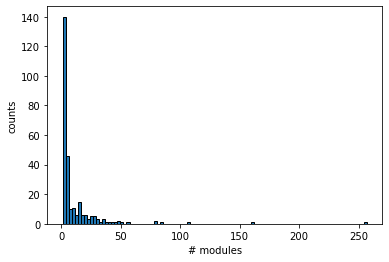

In [48]:
histogram(x2modulesNum, x_axis = '# modules', bins=100)  # 2002, 2003 are >300

## rxn2x = rn2rules

In [50]:
# rxn2x = {}
# for x, reactions in x2rxn.items():
#     for reaction in reactions:
#         if reaction not in rxn2x.keys():
#             rxn2x[reaction] = [x]
#         else:
#             rxn2x[reaction].append(x)

# rxn2x

In [51]:
rn2rules['R01900']

{frozenset({'2487', '7542'}), frozenset({'109', '2487', '7542'})}

## module2x

In [52]:
module2rxn

{'M00001': ['R01786',
  'R02189',
  'R09085',
  'R13199',
  'R00756',
  'R05805',
  'R01070',
  'R01015',
  'R01061',
  'R01063',
  'R01512',
  'R07159',
  'R01518',
  'R00658',
  'R00200'],
 'M00002': ['R01015',
  'R01061',
  'R01063',
  'R01512',
  'R07159',
  'R01518',
  'R00658',
  'R00200'],
 'M00003': ['R00431',
  'R00726',
  'R00341',
  'R00658',
  'R01518',
  'R01512',
  'R01061',
  'R01063',
  'R01015',
  'R01070',
  'R00762'],
 'M00004': ['R02736',
  'R10907',
  'R02035',
  'R01528',
  'R10221',
  'R01529',
  'R01056',
  'R01641',
  'R08575',
  'R01067',
  'R13199',
  'R02739'],
 'M00005': ['R01049'],
 'M00006': ['R02736', 'R10907', 'R02035', 'R01528', 'R10221'],
 'M00007': ['R01067', 'R08575', 'R01641', 'R01529', 'R01056'],
 'M00008': ['R02736', 'R02035', 'R02036', 'R05605'],
 'M00009': ['R00351',
  'R01325',
  'R01900',
  'R01324',
  'R01899',
  'R00268',
  'R00267',
  'R00709',
  'R00621',
  'R03316',
  'R01700',
  'R02570',
  'R07618',
  'R01197',
  'R00405',
  'R00432',


In [53]:
# let's reconcile versions here

rn2rulesSET = {}
for rn, rules in rn2rules.items():
    rn_new = rn[:6]
    if rn_new not in rn2rulesSET.keys():  # eliminate mumltiple versions
        rulesSET = []
        for rule in rules:
            rulesSET.append(set(rule)) 
        rn2rulesSET[rn] = rulesSET

In [54]:
len(rn2rulesSET.keys())  # 12872 with versions, 8217 without versions

8217

In [55]:
module2x = {}
rxnNOTrn2rules = set()
for module, reactions in module2rxn.items():  # module2rxn is from KEGG => no v1, v2...
    rules = []
    for reaction in reactions:
        try:
            rules.append(rn2rulesSET[reaction])  # rn2rulesSET no longer has v1, v2... => should be ok
        except:
            print(f'{reaction} is not in rn2rules')
            rxnNOTrn2rules.add(reaction)
    if module not in module2x.keys():
        module2x[module] = rules
    else:
        module2x[module].append(rules)

R13199 is not in rn2rules
R13199 is not in rn2rules
R02036 is not in rn2rules
R01905 is not in rn2rules
R13166 is not in rn2rules
R13167 is not in rn2rules
R06264 is not in rn2rules
R05912 is not in rn2rules
R05909 is not in rn2rules
R05915 is not in rn2rules
R05910 is not in rn2rules
R05925 is not in rn2rules
R05918 is not in rn2rules
R05962 is not in rn2rules
R05971 is not in rn2rules
R05971 is not in rn2rules
R08599 is not in rn2rules
R05987 is not in rn2rules
R05991 is not in rn2rules
R05992 is not in rn2rules
R07820 is not in rn2rules
R07817 is not in rn2rules
R07805 is not in rn2rules
R06517 is not in rn2rules
R06519 is not in rn2rules
R09655 is not in rn2rules
R05341 is not in rn2rules
R03824 is not in rn2rules
R06517 is not in rn2rules
R06519 is not in rn2rules
R07509 is not in rn2rules
R12403 is not in rn2rules
R03353 is not in rn2rules
R07215 is not in rn2rules
R07509 is not in rn2rules
R12403 is not in rn2rules
R07491 is not in rn2rules
R07502 is not in rn2rules
R07503 is no

In [56]:
len(rxnNOTrn2rules)  # 230 vs. 8217
# this number didn't change even after recovering v1... turns out we do have R00001, R00001_v1, R00001_v2 etc.

230

In [57]:
for r in rxnNOTrn2rules:
    print(r, rxn2module[r])

R13223 ['M00148']
R05971 ['M00070', 'M00071']
R12912 ['M00951']
R12407 ['M00906']
R05341 ['M00097']
R07447 ['M00371']
R10942 ['M00904']
R13031 ['M00961']
R12935 ['M00950']
R13036 ['M00960']
R11383 ['M00848']
R11627 ['M00836']
R12415 ['M00891']
R13082 ['M00967']
R08824 ['M00961']
R12104 ['M00963']
R10623 ['M00112']
R11414 ['M00833', 'M00834']
R12943 ['M00951']
R13117 ['M00969']
R12584 ['M00923']
R12403 ['M00101', 'M00102']
R07738 ['M00942']
R10944 ['M00904']
R05925 ['M00057']
R10224 ['M00937']
R06781 ['M00545']
R02161 ['M00152']
R12114 ['M00890']
R08863 ['M00903']
R13162 ['M00971']
R13029 ['M00975']
R11120 ['M00805']
R13056 ['M00966']
R13165 ['M00971']
R12026 ['M00896']
R05530 ['M00774']
R09489 ['M00121']
R07961 ['M00915']
R04305 ['M00943']
R13104 ['M00969']
R12093 ['M00964']
R10624 ['M00112']
R07902 ['M00113']
R10470 ['M00785']
R12294 ['M00872']
R03112 ['M00937']
R07473 ['M00371']
R12352 ['M00904']
R13035 ['M00957']
R13090 ['M00968']
R06264 ['M00055']
R09542 ['M00163']
R10401 ['M00937'

## why are there so many reactions that are NOT included in rn2rules?
## Also, some KEGG Modules do not have any Reactions...

In [58]:
module2x  # R = [set, set, set], module = [[set, set], [set, set]]

{'M00001': [[{'2484'}],
  [{'2484'}],
  [{'2003'}],
  [{'2007', '7572'}],
  [{'2003'}],
  [{'304'}, {'2002'}],
  [{'2002'}],
  [{'2003', '298'}],
  [{'2003', '298'}],
  [{'7532', '7533'}],
  [{'169', '806'}],
  [{'7515', '7554'}, {'304', '7515'}, {'7525'}],
  [{'2002', '218'}],
  [{'1', '7518'}]],
 'M00002': [[{'2002'}],
  [{'2003', '298'}],
  [{'2003', '298'}],
  [{'7532', '7533'}],
  [{'169', '806'}],
  [{'7515', '7554'}, {'304', '7515'}, {'7525'}],
  [{'2002', '218'}],
  [{'1', '7518'}]],
 'M00003': [[{'2004'}],
  [{'2004'}],
  [{'2004'}],
  [{'2002', '218'}],
  [{'7515', '7554'}, {'304', '7515'}, {'7525'}],
  [{'7532', '7533'}],
  [{'2003', '298'}],
  [{'2003', '298'}],
  [{'2002'}],
  [{'304'}, {'2002'}],
  [{'4018', '7587'}]],
 'M00004': [[{'2003', '298'}],
  [{'2003', '298'}, {'2003'}],
  [{'2003', '298'}, {'2003'}, {'5'}],
  [{'129', '2003'}],
  [{'129', '2003'}],
  [{'2002'}],
  [{'2003', '304'}, {'7560'}],
  [{'7522', '7574'}],
  [{'2002'}],
  [{'7522', '7574'}],
  [{'2007'},

# NOW we have everything we need

In [59]:
print(len(rn2rules))
print(len(rxn2module))

print(len(x2modules))  # 274 out of 397 are associated with a module
print(len(x2rxn))

print(len(module2rxn))
print(len(module2x))

12872
2110
274
397
479
479


# Uniquely associated (SingleModuleX) fold

In [60]:
singleModuleX = {}
for key, values in x2modulesNum.items():
    if x2modulesNum[key] == 1:
        singleModuleX[key] = list(x2modules[key])[0]

In [61]:
singleModuleX

{'7553': 'M00122',
 '4048': 'M00532',
 '136': 'M00043',
 '4004': 'M00100',
 '881': 'M00532',
 '300': 'M00093',
 '4022': 'M00045',
 '7500': 'M00346',
 '1055': 'M00877',
 '239': 'M00026',
 '7513': 'M00378',
 '875': 'M00022',
 '376': 'M00035',
 '158': 'M00113',
 '319': 'M00055',
 '102': 'M00053',
 '842': 'M00938',
 '4237': 'M00903',
 '3688': 'M00117',
 '4076': 'M00736',
 '374': 'M00418',
 '309': 'M00609',
 '148': 'M00529',
 '876': 'M00875',
 '185': 'M00114',
 '7551': 'M00358',
 '3001': 'M00016',
 '6096': 'M00124',
 '4126': 'M00065',
 '6051': 'M00776',
 '180': 'M00089',
 '4028': 'M00532',
 '258': 'M00017',
 '4019': 'M00893',
 '814': 'M00117',
 '528': 'M00055',
 '582': 'M00174',
 '3115': 'M00878',
 '303': 'M00133',
 '7504': 'M00938',
 '4160': 'M00622',
 '2010': 'M00344',
 '5084': 'M00867',
 '590': 'M00344',
 '214': 'M00130',
 '270': 'M00761',
 '3691': 'M00114',
 '3052': 'M00880',
 '3896': 'M00093',
 '4295': 'M00088',
 '7567': 'M00065',
 '601': 'M00089',
 '9': 'M00113',
 '869': 'M00567',
 '3

In [62]:
x2names = csv2dict('../data/assets/xgroup2/xgroup2names.csv')

In [63]:
for x in singleModuleX.keys():
    print(x, x2names.get(x, "NO NAME"),singleModuleX[x], modules[singleModuleX[x]])

7553 NO NAME M00122 Cobalamin biosynthesis, cobyrinate a,c-diamide => cobalamin
4048 NO NAME M00532 Photorespiration
136 NO NAME M00043 Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine
4004 NO NAME M00100 Sphingosine degradation
881 Mog1p/PsbP-like M00532 Photorespiration
300 NO NAME M00093 Phosphatidylethanolamine (PE) biosynthesis, PA => PS => PE
4022 NO NAME M00045 Histidine degradation, histidine => N-formiminoglutamate => glutamate
7500 NO NAME M00346 Formaldehyde assimilation, serine pathway
1055 NO NAME M00877 Kanosamine biosynthesis, glucose 6-phosphate => kanosamine
239 Ribosomal protein L25-like M00026 Histidine biosynthesis, PRPP => histidine
7513 NO NAME M00378 F420 biosynthesis, archaea
875 NO NAME M00022 Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
376 RING/U-box-like M00035 Methionine degradation
158 NO NAME M00113 Jasmonic acid biosynthesis
319 HSP20-like M00055 N-glycan precursor biosynthesis
102 HhH/H2TH M00053 Deoxyribonucle

In [64]:
singleModuleXset = set(singleModuleX.keys())
print(singleModuleXset)

{'875', '3052', '4028', '601', '4022', '582', '590', '136', '270', '3691', '2010', '374', '7536', '6096', '4110', '4076', '376', '3001', '148', '158', '876', '258', '814', '7513', '629', '4295', '7553', '185', '199', '3754', '881', '309', '102', '319', '869', '180', '214', '640', '4048', '239', '3896', '3115', '7551', '7504', '1055', '9', '4019', '3688', '300', '4126', '4160', '7500', '7567', '5084', '4004', '842', '4237', '6051', '4021', '528', '303'}


# absolutely required (formerly called 'unique')

A fold is Abs. Req. for a reaction if that fold appears in ALL rules associated with the reaction

A fold is Abs. Req. for a module if that fold is Abs. Req. in ALL reactions associated with the module

In [65]:
xgroup = '2003'
for module, reactions in module2x.items():
    if len(module2x[module]) == 0:
        continue
    counter = 0
    for reaction in reactions:
        innerCounter = 0
        for rule in reaction:
            if xgroup in rule:
                innerCounter += 1
        if innerCounter == len(reaction):
            counter += 1
    if counter == len(reactions):
        print(f'{xgroup} is absolutely required for {module}')

2003 is absolutely required for M00547
2003 is absolutely required for M00784
2003 is absolutely required for M00949


In [66]:
def arFor(xgroup):
    x2AbsReqModules = {xgroup:[]}    
    for module, reactions in module2x.items():
        if len(module2x[module]) == 0:
            continue
        counter = 0
        for reaction in reactions:
            innerCounter = 0
            for rule in reaction:
                if xgroup in rule:
                    innerCounter += 1
            if innerCounter == len(reaction):
                counter += 1
        if counter == len(reactions):
            print(f'X{xgroup} ({x2names.get(xgroup, "NO X NAME")}) is abs. req. for {module}: {modules[module]}')
            x2AbsReqModules[xgroup].append(module)
    return x2AbsReqModules

In [67]:
x2AbsReqModules = {}
for xgroup in x2ns.keys():
    new_dict = arFor(xgroup)
    if new_dict[xgroup] != []:
        x2AbsReqModules.update(new_dict)

X136 (NO X NAME) is abs. req. for M00043: Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine
X7514 (NO X NAME) is abs. req. for M00548: Benzene degradation, benzene => catechol
X7514 (NO X NAME) is abs. req. for M00638: Salicylate degradation, salicylate => gentisate
X1 (cradle loop barrel) is abs. req. for M00548: Benzene degradation, benzene => catechol
X1 (cradle loop barrel) is abs. req. for M00638: Salicylate degradation, salicylate => gentisate
X331 (TBP-like) is abs. req. for M00637: Anthranilate degradation, anthranilate => catechol
X331 (TBP-like) is abs. req. for M00638: Salicylate degradation, salicylate => gentisate
X331 (TBP-like) is abs. req. for M00967: Flavone degradation, luteolin/apigenin => DHCA/phloretate
X246 (Carbon-nitrogen hydrolase-like) is abs. req. for M00595: Thiosulfate oxidation by SOX complex, thiosulfate => sulfate
X4011 (NO X NAME) is abs. req. for M00086: beta-Oxidation, acyl-CoA synthesis
X2485 (Thioredoxin-like) is abs. req. for M00

X2003 (Rossmann-like) is abs. req. for M00547: Benzene/toluene degradation, benzene => catechol / toluene => 3-methylcatechol
X2003 (Rossmann-like) is abs. req. for M00784: Elloramycin biosynthesis, 8-demethyltetracenomycin C => elloramycin A
X2003 (Rossmann-like) is abs. req. for M00949: Staphylopine biosynthesis, L-histidine => staphylopine
X2004 (P-loop domains-like) is abs. req. for M00175: Nitrogen fixation, nitrogen => ammonia
X149 (NO X NAME) is abs. req. for M00108: C21-Steroid hormone biosynthesis, progesterone => corticosterone/aldosterone
X149 (NO X NAME) is abs. req. for M00371: Castasterone biosynthesis, campesterol => castasterone
X187 (alpha-helical ferredoxin-like) is abs. req. for M00149: Succinate dehydrogenase, prokaryotes
X187 (alpha-helical ferredoxin-like) is abs. req. for M00150: Fumarate reductase, prokaryotes
X304 (Alpha-beta plaits) is abs. req. for M00548: Benzene degradation, benzene => catechol


In [68]:
len(x2AbsReqModules)

42

In [69]:
x2AbsReqModules

{'136': ['M00043'],
 '7514': ['M00548', 'M00638'],
 '1': ['M00548', 'M00638'],
 '331': ['M00637', 'M00638', 'M00967'],
 '246': ['M00595'],
 '4011': ['M00086'],
 '2485': ['M00072'],
 '3156': ['M00154', 'M00155', 'M00156', 'M00417'],
 '150': ['M00548'],
 '7512': ['M00900'],
 '206': ['M00132'],
 '5039': ['M00154', 'M00155', 'M00156'],
 '5038': ['M00154', 'M00155', 'M00156', 'M00417'],
 '328': ['M00068'],
 '107': ['M00154', 'M00155', 'M00156', 'M00595'],
 '3456': ['M00142', 'M00143', 'M00144', 'M00145', 'M00146', 'M00147'],
 '11': ['M00595'],
 '221': ['M00068', 'M00149', 'M00150', 'M00548', 'M00595', 'M00638'],
 '207': ['M00081'],
 '3579': ['M00142', 'M00143', 'M00144', 'M00145', 'M00146', 'M00147'],
 '2002': ['M00916'],
 '7516': ['M00056', 'M00058', 'M00059', 'M00066', 'M00070', 'M00071'],
 '243': ['M00637', 'M00638'],
 '5069': ['M00149', 'M00150', 'M00153'],
 '7573': ['M00005'],
 '805': ['M00595'],
 '2007': ['M00175', 'M00916'],
 '604': ['M00149', 'M00150'],
 '66': ['M00637', 'M00638'],


In [70]:
set(x2AbsReqModules.keys()) & singleModuleXset

{'136'}

In [71]:
# only one!
x = '136'
print(f'X{x}, #rxn={len(x2rxn[x])} ({x2names.get(x, "NO X NAME")}) {list(x2modules[x])[0]}: {modules[list(x2modules[x])[0]]}')

X136, #rxn=65 (NO X NAME) M00043: Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine


In [72]:
module2rxn['M00043']

['R03539', 'R03973', 'R03953', 'R03208']

In [73]:
for rxn in module2rxn['M00043']:
    print(rn2rules[rxn])

{frozenset({'389', '136'})}
{frozenset({'389', '136'})}
{frozenset({'389', '136'})}
{frozenset({'389', '136'})}


In [74]:
x2names['389']

'EGF-like'

In [75]:
for rxn in x2rxn['136']:
    print(rxn, rxn2module.get(rxn, 'NO MODULE'))

R03539 ['M00043']
R03973 ['M00043']
R03208 ['M00043']
R03953 ['M00043']
R09905 NO MODULE
R00644 NO MODULE
R07062 NO MODULE
R00698 NO MODULE
R09811 NO MODULE
R09540 NO MODULE
R00073 NO MODULE
R00602 NO MODULE
R01590 NO MODULE
R02596 NO MODULE
R02670 NO MODULE
R03919 NO MODULE
R04007 NO MODULE
R07061 NO MODULE
R07443 NO MODULE
R11906 NO MODULE
R00011 NO MODULE
R02810 NO MODULE
R04461 NO MODULE
R07172 NO MODULE
R08520 NO MODULE
R08521 NO MODULE
R08522 NO MODULE
R08523 NO MODULE
R09564 NO MODULE
R11501 NO MODULE
R11502 NO MODULE
R03532 NO MODULE
R01599 NO MODULE
R07171 NO MODULE
R00011_v1 NO MODULE
R07062_v1 NO MODULE
R09905_v1 NO MODULE
R03539_v1 NO MODULE
R04461_v1 NO MODULE
R08520_v1 NO MODULE
R07172_v1 NO MODULE
R07443_v1 NO MODULE
R11502_v1 NO MODULE
R11906_v1 NO MODULE
R09540_v1 NO MODULE
R07171_v1 NO MODULE
R00644_v1 NO MODULE
R03973_v1 NO MODULE
R08523_v1 NO MODULE
R00698_v1 NO MODULE
R09564_v1 NO MODULE
R08521_v1 NO MODULE
R07061_v1 NO MODULE
R08522_v1 NO MODULE
R00602_v1 NO MODUL

## Liam: relax the Abs Req. criteria for modules. ONE Reaction is enough.

In [76]:
def arFor2(xgroup):
    x2AbsReqModules = {xgroup:[]}    
    for module, reactions in module2x.items():
        if len(module2x[module]) == 0:
            continue
        counter = 0
        for reaction in reactions:
            innerCounter = 0
            for rule in reaction:
                if xgroup in rule:
                    innerCounter += 1
            if innerCounter == len(reaction):
                counter += 1
        if counter > 0:
            print(f'X{xgroup} ({x2names.get(xgroup, "NO X NAME")}) is abs. req. for {module}: {modules[module]}')
            x2AbsReqModules[xgroup].append(module)
    return x2AbsReqModules

In [77]:
x2AbsReqModules = {}
for xgroup in x2ns.keys():
    new_dict = arFor2(xgroup)
    if new_dict[xgroup] != []:
        x2AbsReqModules.update(new_dict)

X7553 (NO X NAME) is abs. req. for M00122: Cobalamin biosynthesis, cobyrinate a,c-diamide => cobalamin
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. for M00009: Citrate cycle (TCA cycle, Krebs cycle)
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. for M00010: Citrate cycle, first carbon oxidation, oxaloacetate => 2-oxoglutarate
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. for M00012: Glyoxylate cycle
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. for M00029: Urea cycle
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. for M00030: Lysine biosynthesis, AAA pathway, 2-oxoglutarate => 2-aminoadipate => lysine
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. for M00051: De novo pyrimidine biosynthesis, glutamine (+ PRPP) => UMP
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. for M00169: CAM (Crassulacean acid metabolism), light
X2487 (The "swivelling" beta/beta/alpha domains) is abs. req. fo

X6 (NO X NAME) is abs. req. for M00872: O-glycan biosynthesis, mannose type (core M3)
X257 (NO X NAME) is abs. req. for M00037: Melatonin biosynthesis, animals, tryptophan => serotonin => melatonin
X257 (NO X NAME) is abs. req. for M00042: Catecholamine biosynthesis, tyrosine => dopamine => noradrenaline => adrenaline
X3740 (NO X NAME) is abs. req. for M00356: Methanogenesis, methanol => methane
X3740 (NO X NAME) is abs. req. for M00357: Methanogenesis, acetate => methane
X3740 (NO X NAME) is abs. req. for M00563: Methanogenesis, methylamine/dimethylamine/trimethylamine => methane
X3740 (NO X NAME) is abs. req. for M00567: Methanogenesis, CO2 => methane
X331 (TBP-like) is abs. req. for M00034: Methionine salvage pathway
X331 (TBP-like) is abs. req. for M00133: Polyamine biosynthesis, arginine => agmatine => putrescine => spermidine
X331 (TBP-like) is abs. req. for M00534: Naphthalene degradation, naphthalene => salicylate
X331 (TBP-like) is abs. req. for M00539: Cumate degradation, p-c

X4018 (NO X NAME) is abs. req. for M00003: Gluconeogenesis, oxaloacetate => fructose-6P
X4018 (NO X NAME) is abs. req. for M00114: Ascorbate biosynthesis, plants, fructose-6P => ascorbate
X4018 (NO X NAME) is abs. req. for M00131: Inositol phosphate metabolism, Ins(1,3,4,5)P4 => Ins(1,3,4)P3 => myo-inositol
X4018 (NO X NAME) is abs. req. for M00165: Reductive pentose phosphate cycle (Calvin cycle)
X4018 (NO X NAME) is abs. req. for M00344: Formaldehyde assimilation, xylulose monophosphate pathway
X4018 (NO X NAME) is abs. req. for M00889: Puromycin biosynthesis, ATP => puromycin
X2485 (Thioredoxin-like) is abs. req. for M00044: Tyrosine degradation, tyrosine => homogentisate
X2485 (Thioredoxin-like) is abs. req. for M00072: N-glycosylation by oligosaccharyltransferase
X2485 (Thioredoxin-like) is abs. req. for M00176: Assimilatory sulfate reduction, sulfate => H2S
X2485 (Thioredoxin-like) is abs. req. for M00534: Naphthalene degradation, naphthalene => salicylate
X2485 (Thioredoxin-like

X3016 (NO X NAME) is abs. req. for M00025: Tyrosine biosynthesis, chorismate => HPP => tyrosine
X3016 (NO X NAME) is abs. req. for M00026: Histidine biosynthesis, PRPP => histidine
X3016 (NO X NAME) is abs. req. for M00027: GABA (gamma-Aminobutyrate) shunt
X3016 (NO X NAME) is abs. req. for M00028: Ornithine biosynthesis, glutamate => ornithine
X3016 (NO X NAME) is abs. req. for M00030: Lysine biosynthesis, AAA pathway, 2-oxoglutarate => 2-aminoadipate => lysine
X3016 (NO X NAME) is abs. req. for M00031: Lysine biosynthesis, mediated by LysW, 2-aminoadipate => lysine
X3016 (NO X NAME) is abs. req. for M00032: Lysine degradation, lysine => saccharopine => acetoacetyl-CoA
X3016 (NO X NAME) is abs. req. for M00033: Ectoine biosynthesis, aspartate => ectoine
X3016 (NO X NAME) is abs. req. for M00034: Methionine salvage pathway
X3016 (NO X NAME) is abs. req. for M00037: Melatonin biosynthesis, animals, tryptophan => serotonin => melatonin
X3016 (NO X NAME) is abs. req. for M00038: Tryptopha

X633 (Bromodomain-like) is abs. req. for M00827: C-1027 beta-amino acid moiety biosynthesis, tyrosine => 3-chloro-4,5-dihydroxy-beta-phenylalanyl-PCP
X633 (Bromodomain-like) is abs. req. for M00837: Prodigiosin biosynthesis, L-proline => prodigiosin
X633 (Bromodomain-like) is abs. req. for M00838: Undecylprodigiosin biosynthesis, L-proline => undecylprodigiosin
X633 (Bromodomain-like) is abs. req. for M00861: beta-Oxidation, peroxisome, VLCFA
X633 (Bromodomain-like) is abs. req. for M00862: beta-Oxidation, peroxisome, tri/dihydroxycholestanoyl-CoA => choloyl/chenodeoxycholoyl-CoA
X633 (Bromodomain-like) is abs. req. for M00957: Lysine degradation, bacteria, L-lysine => glutarate => succinate/acetyl-CoA
X236 (GroES-like) is abs. req. for M00014: Glucuronate pathway (uronate pathway)
X236 (GroES-like) is abs. req. for M00085: Fatty acid elongation in mitochondria
X236 (GroES-like) is abs. req. for M00129: Ascorbate biosynthesis, animals, glucose-1P => ascorbate
X236 (GroES-like) is abs. 

...

X10 (jelly-roll) is abs. req. for M00819: Pentalenolactone biosynthesis, farnesyl-PP => pentalenolactone
X10 (jelly-roll) is abs. req. for M00897: Thiamine biosynthesis, plants, AIR (+ NAD+) => TMP/thiamine/TPP
X10 (jelly-roll) is abs. req. for M00898: Thiamine biosynthesis, pyridoxal-5P => TMP/thiamine/TPP
X10 (jelly-roll) is abs. req. for M00902: Podophyllotoxin biosynthesis, coniferyl alcohol => podophyllotoxin
X10 (jelly-roll) is abs. req. for M00912: NAD biosynthesis, tryptophan => quinolinate => NAD
X10 (jelly-roll) is abs. req. for M00928: Gibberellin A4/A1 biosynthesis, GA12/GA53 => GA4/GA1
X10 (jelly-roll) is abs. req. for M00944: Morphine biosynthesis, (S)-reticuline => morphine
X10 (jelly-roll) is abs. req. for M00952: Benzoxazinoid biosynthesis, indoleglycerol phosphate => DIMBOA-glucoside
X10 (jelly-roll) is abs. req. for M00953: Mugineic acid biosynthesis, methionine => 3-epihydroxymugineic acid
X10 (jelly-roll) is abs. req. for M00956: Lysine degradation, bacteria, L-lys

X7527 (NO X NAME) is abs. req. for M00104: Bile acid biosynthesis, cholesterol => cholate/chenodeoxycholate
X7527 (NO X NAME) is abs. req. for M00376: 3-Hydroxypropionate bi-cycle
X7527 (NO X NAME) is abs. req. for M00418: Toluene degradation, anaerobic, toluene => benzoyl-CoA
X7527 (NO X NAME) is abs. req. for M00740: Methylaspartate cycle
X282 (NO X NAME) is abs. req. for M00063: CMP-KDO biosynthesis
X4262 (NO X NAME) is abs. req. for M00924: Cobalamin biosynthesis, anaerobic, uroporphyrinogen III => sirohydrochlorin => cobyrinate a,c-diamide
X7571 (NO X NAME) is abs. req. for M00048: De novo purine biosynthesis, PRPP + glutamine => IMP
X7571 (NO X NAME) is abs. req. for M00761: Undecaprenylphosphate alpha-L-Ara4N biosynthesis, UDP-GlcA => undecaprenyl phosphate alpha-L-Ara4N
X146 (NO X NAME) is abs. req. for M00042: Catecholamine biosynthesis, tyrosine => dopamine => noradrenaline => adrenaline
X146 (NO X NAME) is abs. req. for M00905: Grixazone biosynthesis, aspartate 4-semialdehyd

X869 (NO X NAME) is abs. req. for M00567: Methanogenesis, CO2 => methane
X602 (L-aspartase middle domain-like) is abs. req. for M00029: Urea cycle
X602 (L-aspartase middle domain-like) is abs. req. for M00039: Monolignol biosynthesis, phenylalanine/tyrosine => monolignol
X602 (L-aspartase middle domain-like) is abs. req. for M00045: Histidine degradation, histidine => N-formiminoglutamate => glutamate
X602 (L-aspartase middle domain-like) is abs. req. for M00048: De novo purine biosynthesis, PRPP + glutamine => IMP
X602 (L-aspartase middle domain-like) is abs. req. for M00049: Adenine ribonucleotide biosynthesis, IMP => ADP,ATP
X602 (L-aspartase middle domain-like) is abs. req. for M00137: Flavanone biosynthesis, phenylalanine => naringenin
X602 (L-aspartase middle domain-like) is abs. req. for M00827: C-1027 beta-amino acid moiety biosynthesis, tyrosine => 3-chloro-4,5-dihydroxy-beta-phenylalanyl-PCP
X602 (L-aspartase middle domain-like) is abs. req. for M00828: Maduropeptin beta-hydr

X187 (alpha-helical ferredoxin-like) is abs. req. for M00563: Methanogenesis, methylamine/dimethylamine/trimethylamine => methane
X187 (alpha-helical ferredoxin-like) is abs. req. for M00567: Methanogenesis, CO2 => methane
X187 (alpha-helical ferredoxin-like) is abs. req. for M00620: Incomplete reductive citrate cycle, acetyl-CoA => oxoglutarate
X3651 (NO X NAME) is abs. req. for M00034: Methionine salvage pathway
X3651 (NO X NAME) is abs. req. for M00968: Pentose bisphosphate pathway (nucleoside degradation), archaea, nucleoside/NMP => 3-PGA/glycerone phosphate
X169 (NO X NAME) is abs. req. for M00001: Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate
X169 (NO X NAME) is abs. req. for M00002: Glycolysis, core module involving three-carbon compounds
X169 (NO X NAME) is abs. req. for M00309: Non-phosphorylative Entner-Doudoroff pathway, gluconate/galactonate => glycerate
X169 (NO X NAME) is abs. req. for M00541: Benzoyl-CoA degradation, benzoyl-CoA => 3-hydroxypimeloyl-CoA
X867 

X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00030: Lysine biosynthesis, AAA pathway, 2-oxoglutarate => 2-aminoadipate => lysine
X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00034: Methionine salvage pathway
X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00035: Methionine degradation
X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00039: Monolignol biosynthesis, phenylalanine/tyrosine => monolignol
X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00050: Guanine ribonucleotide biosynthesis, IMP => GDP,GTP
X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00104: Bile acid biosynthesis, cholesterol => cholate/chenodeoxycholate
X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00106: Conjugated bile acid biosynthesis, cholate => taurocholate/glycocholate
X327 (Alpha-lytic protease prodomain-like) is abs. req. for M00113: Jasmonic acid biosynthesis
X327 (Alpha-lytic protease prodomain-like) is abs. 

In [78]:
arSet = set(x2AbsReqModules.keys())

In [79]:
len(arSet)

235

In [80]:
arua = arSet & singleModuleXset
len(arua)

44

In [81]:
# absolutely required AND uniquely associated
for x in arua:
    print(f'X{x}, #rxn={len(x2rxn[x])} ({x2names.get(x, "NO X NAME")}) {list(x2modules[x])[0]}: {modules[list(x2modules[x])[0]]}')

X875, #rxn=2 (NO X NAME) M00022: Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
X3052, #rxn=8 (NO X NAME) M00880: Molybdenum cofactor biosynthesis, GTP => molybdenum cofactor
X4028, #rxn=5 (NO X NAME) M00532: Photorespiration
X4022, #rxn=2 (NO X NAME) M00045: Histidine degradation, histidine => N-formiminoglutamate => glutamate
X582, #rxn=8 (NO X NAME) M00174: Methane oxidation, methanotroph, methane => formaldehyde
X590, #rxn=11 (NO X NAME) M00344: Formaldehyde assimilation, xylulose monophosphate pathway
X136, #rxn=65 (NO X NAME) M00043: Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine
X270, #rxn=5 (FMT C-terminal domain-like) M00761: Undecaprenylphosphate alpha-L-Ara4N biosynthesis, UDP-GlcA => undecaprenyl phosphate alpha-L-Ara4N
X2010, #rxn=17 (NO X NAME) M00344: Formaldehyde assimilation, xylulose monophosphate pathway
X374, #rxn=5 (NO X NAME) M00418: Toluene degradation, anaerobic, toluene => benzoyl-CoA
X6096, #rxn=1 (NO X NAME) M00124: 

In [82]:
first10 = {'325', '2002', '218', '206', '4953', '2003', '2007', '602', '2005', '4952'}

In [83]:
first10 & arua

set()

In [84]:
xgroup2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')

In [85]:
# look at network size < 3600 vs. ≥ 3600

group1 = {}
group2 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 3600:
        group1[xgroup] = xgroup2ns[xgroup]
    else:
        group2[xgroup] = xgroup2ns[xgroup]

In [86]:
group1.keys()

dict_keys(['3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'])

In [87]:
set(group1.keys()) & arua

{'875'}

In [88]:
# len (abs. req. & uniquely associated) = 44
# only 1 / 37 from Class I is "abs. req. & uniquely associated"!
# Class II: 43 / 360

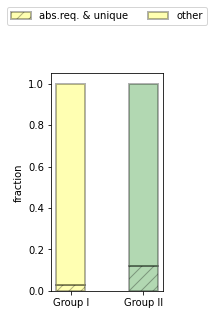

In [89]:
categories = ['Group I', 'Group II']
ar_unique_values = [1/37, 43/360]
other_values = [36/37, 317/360]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1]
fig, ax = plt.subplots(figsize=(2, 4))


plt.bar(bar_positions, ar_unique_values, label='abs.req. & unique', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//', width=bar_width, color=['yellow', 'green'])
plt.bar(bar_positions, other_values, bottom=ar_unique_values, label='other', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, width=bar_width, color=['yellow', 'green'])

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# plt.savefig('AbsReqUniq_ns_bar.png', bbox_inches='tight')
plt.show()


### check their DS

# DS average

In [90]:
a_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'

xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict(e_path)
print(len(xgroup2ds_e))

2230
2230
2230


In [91]:
print(arua)

{'875', '3052', '4028', '4022', '582', '590', '136', '270', '2010', '374', '6096', '4110', '4076', '3001', '876', '158', '7513', '4295', '7553', '185', '199', '3754', '309', '319', '869', '640', '4048', '239', '3896', '3115', '7551', '1055', '9', '4019', '3688', '4126', '4160', '7567', '5084', '4004', '842', '4237', '6051', '528'}


In [92]:
print(' x   a    b   e')
print('--------------------------------------------------------------')
for x in arua:
    print(x, round(xgroup2ds_a[x], 2), round(xgroup2ds_b[x], 2), round(xgroup2ds_e[x], 2),
         next(iter(x2modules[x])), modules[next(iter(x2modules[x]))])

 x   a    b   e
--------------------------------------------------------------
875 0.4 0.7 0.61 M00022 Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
3052 0.38 0.54 0.71 M00880 Molybdenum cofactor biosynthesis, GTP => molybdenum cofactor
4028 0.05 0.14 0.62 M00532 Photorespiration
4022 0.09 0.34 0.47 M00045 Histidine degradation, histidine => N-formiminoglutamate => glutamate
582 0.0 0.0 0.0 M00174 Methane oxidation, methanotroph, methane => formaldehyde
590 0.02 0.09 0.64 M00344 Formaldehyde assimilation, xylulose monophosphate pathway
136 0.07 0.16 0.88 M00043 Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine
270 0.15 0.92 0.44 M00761 Undecaprenylphosphate alpha-L-Ara4N biosynthesis, UDP-GlcA => undecaprenyl phosphate alpha-L-Ara4N
2010 0.03 0.5 0.64 M00344 Formaldehyde assimilation, xylulose monophosphate pathway
374 0.0 0.01 0.02 M00418 Toluene degradation, anaerobic, toluene => benzoyl-CoA
6096 0.0 0.05 0.02 M00124 Pyridoxal-P biosynthesis, 

# domain-specific folds (ArcBacEuk)

In [93]:
a_only = {'5103'}
b_only = {'4036', '4035', '914', '3018', '582', '6051', '3339', '4054', '640', '6113', '1055', '3847', '6174'}
e_only = {'3322', '3257', '558', '3777', '3371'}

In [94]:
x2architecture = csv2dict('../data/assets/xgroup2/xgroup2architecture.csv')

## Arc

In [95]:
x2rxn['5103']  # ADP + L-Serine <=> AMP + O-Phospho-L-serine

['R12342']

In [96]:
rn2rules['R12342']

{frozenset({'5103', '876'})}

In [97]:
x2names.get('5103', 'NO NAME')

'NO NAME'

In [98]:
for x in a_only:
    print('------------------------')
    print('------------------------')
    print(f"X{x}, {x2names.get(x, 'NO NAME')}, {x2architecture[x]}")
    module_list = x2modules.get(x, 0)
    if module_list != 0:
        for module in x2modules.get(x, 0):
            print(module, modules[module])
    else:
        print('NO MODULE')
    print('------------------------')
    reactions = x2rxn[x]
    for rxn in reactions:
        print(rxn, rn2rules[rxn])

------------------------
------------------------
X5103, NO NAME, a/b three-layered sandwiches
NO MODULE
------------------------
R12342 {frozenset({'5103', '876'})}


## Bac

In [99]:
for x in b_only:
    print(x2names.get(x, 'NO NAME'))

NO NAME
NO NAME
NO NAME
Methane monooxygenase hydrolase gamma subunit-like
NO NAME
NO NAME
NO NAME
NO NAME
NO NAME
NO NAME
NO NAME
Docking domains in modular polyketide synthases
NO NAME


In [100]:
for x in b_only:
    print('------------------------')
    print(f"X{x}, {x2names.get(x, 'NO NAME')}, {x2architecture[x]}")
    module_list = x2modules.get(x, 0)
    if module_list != 0:
        for module in x2modules.get(x, 0):
            print(module, modules[module])
    else:
        print('NO MODULE')
#     print('------------------------')
#     reactions = x2rxn[x]
#     for rxn in reactions:
#         print(rxn, rn2rules[rxn])

------------------------
X4036, NO NAME, a+b two layers
NO MODULE
------------------------
X4035, NO NAME, a+b three layers
NO MODULE
------------------------
X3339, NO NAME, alpha bundles
NO MODULE
------------------------
X640, Methane monooxygenase hydrolase gamma subunit-like, alpha arrays
M00174 Methane oxidation, methanotroph, methane => formaldehyde
------------------------
X3018, NO NAME, a+b two layers
NO MODULE
------------------------
X582, NO NAME, extended segments
M00174 Methane oxidation, methanotroph, methane => formaldehyde
------------------------
X3847, NO NAME, alpha bundles
NO MODULE
------------------------
X6174, NO NAME, alpha arrays
NO MODULE
------------------------
X914, NO NAME, few secondary structure elements
NO MODULE
------------------------
X4054, NO NAME, alpha bundles
NO MODULE
------------------------
X1055, NO NAME, a/b three-layered sandwiches
M00877 Kanosamine biosynthesis, glucose 6-phosphate => kanosamine
------------------------
X6051, Docking 

## Euk

In [101]:
for x in e_only:
    print(x2names.get(x, 'NO NAME'))

NO NAME
NO NAME
NO NAME
NO NAME
NO NAME


In [102]:
for x in e_only:
    print('------------------------')
    print('------------------------')
    print(f"X{x}, {x2names.get(x, 'NO NAME')}, {x2architecture[x]}")
    module_list = x2modules.get(x, 0)
    if module_list != 0:
        for module in x2modules.get(x, 0):
            print(module, modules[module])
    else:
        print('NO MODULE')
#     print('------------------------')
#     reactions = x2rxn[x]
#     for rxn in reactions:
#         print(rxn, rn2rules[rxn])

------------------------
------------------------
X3371, NO NAME, few secondary structure elements
NO MODULE
------------------------
------------------------
X3777, NO NAME, alpha bundles
NO MODULE
------------------------
------------------------
X3257, NO NAME, a+b complex topology
NO MODULE
------------------------
------------------------
X3322, NO NAME, alpha bundles
M00083 Fatty acid biosynthesis, elongation
M00082 Fatty acid biosynthesis, initiation
------------------------
------------------------
X558, NO NAME, alpha duplicates or obligate multimers
NO MODULE


In [103]:
# Annotations for Reactions from KEGG:

# '3322'
    # a lot of reactions...
# '3257'
    # R04404: 1-Phosphatidyl-D-myo-inositol 4,5-bisphosphate + H2O <=> 1-Phosphatidyl-1D-myo-inositol 4-phosphate + Orthophosphate
    # R09827: Phosphatidylinositol-3,4,5-trisphosphate + H2O <=> 1-Phosphatidyl-1D-myo-inositol 3,4-bisphosphate + Orthophosphate
    # R11680: 1-Phosphatidyl-1D-myo-inositol 4-phosphate + H2O <=> 1-Phosphatidyl-D-myo-inositol + Orthophosphate
# '558'
    # R04452: 2-Acetyl-1-alkyl-sn-glycero-3-phosphocholine + H2O <=> 1-Organyl-2-lyso-sn-glycero-3-phosphocholine + Acetate
# '3777'
    # R01252: L-Proline + 2-Oxoglutarate + Oxygen <=> Hydroxyproline + Succinate + CO2
    # R03219: Procollagen L-proline + 2-Oxoglutarate + Oxygen <=> Procollagen trans-4-hydroxy-L-proline + Succinate + CO2
# '3371'
    # R00164: Phosphoprotein + H2O <=> Protein + Orthophosphate

# Alternatively, look at KEGG PATHWAY "maps", not KEGG MODULE?

In [104]:
url = 'https://rest.kegg.jp/list/pathway'
response = requests.get(url)

if response.status_code == 200:
    counter = 0
    for line in response.text.split('\n'):
        print(line)
        counter += 1
    print(counter)
else:
    print(f"Error: {response.status_code}")

# It's 570 because of the final \n blank line. It's 569 maps in total

map01100	Metabolic pathways
map01110	Biosynthesis of secondary metabolites
map01120	Microbial metabolism in diverse environments
map01200	Carbon metabolism
map01210	2-Oxocarboxylic acid metabolism
map01212	Fatty acid metabolism
map01230	Biosynthesis of amino acids
map01232	Nucleotide metabolism
map01250	Biosynthesis of nucleotide sugars
map01240	Biosynthesis of cofactors
map01220	Degradation of aromatic compounds
map00010	Glycolysis / Gluconeogenesis
map00020	Citrate cycle (TCA cycle)
map00030	Pentose phosphate pathway
map00040	Pentose and glucuronate interconversions
map00051	Fructose and mannose metabolism
map00052	Galactose metabolism
map00053	Ascorbate and aldarate metabolism
map00500	Starch and sucrose metabolism
map00520	Amino sugar and nucleotide sugar metabolism
map00620	Pyruvate metabolism
map00630	Glyoxylate and dicarboxylate metabolism
map00640	Propanoate metabolism
map00650	Butanoate metabolism
map00660	C5-Branched dibasic acid metabolism
map00562	Inositol phosphate metabol

In [105]:
map2description = {}
url = 'https://rest.kegg.jp/list/pathway'
response = requests.get(url)

if response.status_code == 200:
    for line in response.text.split('\n'):
        try:
            mapname = line.split('\t')[0]
            description = line.split('\t')[1]
            map2description[mapname] = description
        except IndexError:
            break
else:
    print(f"Error: {response.status_code}")

In [106]:
print(len(map2description))
map2description

569


{'map01100': 'Metabolic pathways',
 'map01110': 'Biosynthesis of secondary metabolites',
 'map01120': 'Microbial metabolism in diverse environments',
 'map01200': 'Carbon metabolism',
 'map01210': '2-Oxocarboxylic acid metabolism',
 'map01212': 'Fatty acid metabolism',
 'map01230': 'Biosynthesis of amino acids',
 'map01232': 'Nucleotide metabolism',
 'map01250': 'Biosynthesis of nucleotide sugars',
 'map01240': 'Biosynthesis of cofactors',
 'map01220': 'Degradation of aromatic compounds',
 'map00010': 'Glycolysis / Gluconeogenesis',
 'map00020': 'Citrate cycle (TCA cycle)',
 'map00030': 'Pentose phosphate pathway',
 'map00040': 'Pentose and glucuronate interconversions',
 'map00051': 'Fructose and mannose metabolism',
 'map00052': 'Galactose metabolism',
 'map00053': 'Ascorbate and aldarate metabolism',
 'map00500': 'Starch and sucrose metabolism',
 'map00520': 'Amino sugar and nucleotide sugar metabolism',
 'map00620': 'Pyruvate metabolism',
 'map00630': 'Glyoxylate and dicarboxylate 

In [107]:
# dict2csv(map2description, 'map2description.csv')

In [108]:
# CAUTION: 'map01100': 'Metabolic pathways' is ALL metabolic pathways!
# Let's check the sizes of these maps...

In [109]:
url = f'https://rest.kegg.jp/link/rn/map00190'
response = requests.get(url)

if response.status_code == 200:
    for line in response.text.split('\n'):
        print(line)
else:
    print(f"Error: {response.status_code}")
    
# empty because no reactions

In [110]:
# map2sizes100 = {}

In [111]:
# # run this multiple times...

# for mapname in map2description.keys():
#     if mapname not in map2sizes100.keys():
#         url = f'https://rest.kegg.jp/link/rn/{mapname}'
#         response = requests.get(url)
#         if response.status_code == 200:
#             counter = 0
#             for line in response.text.split('\n'):
#                 counter += 1
#                 if counter > 100:
#                     break
#             map2sizes100[mapname] = counter - 1
#         else:
#             print(f"Error: {response.status_code}")
#             break

In [112]:
# len(map2sizes100) # should be 569

In [113]:
# histogram(map2sizes100, bins=100)

In [114]:
# map2sizes1000 = {}

In [115]:
# # run this multiple times...

# for mapname in map2description.keys():
#     if mapname not in map2sizes1000.keys():
#         url = f'https://rest.kegg.jp/link/rn/{mapname}'
#         response = requests.get(url)
#         if response.status_code == 200:
#             counter = 0
#             for line in response.text.split('\n'):
#                 counter += 1
#                 if counter > 1000:
#                     break
#             map2sizes1000[mapname] = counter - 1
#         else:
#             print(f"Error: {response.status_code}")
#             break

In [116]:
# len(map2sizes1000)  # should be 569

In [117]:
# map2sizes1000

In [118]:
# print(map2description['map01100'], map2sizes1000['map01100'])
# print(map2description['map01110'], map2sizes1000['map01110'])
# print(map2description['map01120'], map2sizes1000['map01120'])

# # these are MEGA maps with size > 1,000
# # ignore these!

# map2rxns
make a dictionary map2rxns EXCLUDING MEGA maps

In [119]:
map2rxns = csv2dict('../data/assets/map2rxn.csv')

In [120]:
map2rxns

{'map01200': ['R00009',
  'R00024',
  'R00134',
  'R00149',
  'R00150',
  'R00199',
  'R00200',
  'R00206',
  'R00209',
  'R00214',
  'R00216',
  'R00220',
  'R00230',
  'R00235',
  'R00237',
  'R00238',
  'R00248',
  'R00258',
  'R00262',
  'R00267',
  'R00315',
  'R00341',
  'R00342',
  'R00343',
  'R00344',
  'R00345',
  'R00351',
  'R00352',
  'R00354',
  'R00355',
  'R00361',
  'R00372',
  'R00402',
  'R00405',
  'R00406',
  'R00432',
  'R00472',
  'R00473',
  'R00475',
  'R00479',
  'R00519',
  'R00524',
  'R00527',
  'R00582',
  'R00586',
  'R00588',
  'R00604',
  'R00608',
  'R00614',
  'R00658',
  'R00705',
  'R00706',
  'R00709',
  'R00727',
  'R00740',
  'R00742',
  'R00756',
  'R00762',
  'R00833',
  'R00897',
  'R00919',
  'R00934',
  'R00943',
  'R00945',
  'R01011',
  'R01015',
  'R01049',
  'R01056',
  'R01058',
  'R01061',
  'R01063',
  'R01067',
  'R01068',
  'R01082',
  'R01142',
  'R01146',
  'R01171',
  'R01175',
  'R01196',
  'R01197',
  'R01220',
  'R01221',
  'R

In [121]:
# map2rxns = {}

In [122]:
# for mapname in map2description.keys():
#     # ignore MEGA maps
#     if mapname in {'map01100', 'map01110', 'map01120'}:
#         pass
    
#     else:
#         if mapname not in map2rxns.keys():
#             url = f'https://rest.kegg.jp/link/rn/{mapname}'
#             response = requests.get(url)

#             if response.status_code == 200:
#                 print(mapname)
#                 for line in response.text.split('\n'):
#                     try:
#                         mapname = line.split('\t')[0][5:]
#                         rn = line.split('\t')[1][3:]
#                         if mapname not in map2rxns.keys():
#                             map2rxns[mapname] = [rn]
#                         else:
#                             map2rxns[mapname].append(rn)
#                     except IndexError:
#                         print(f"{mapname} can't be parsed. map with NO reactions")
#                         pass
#             else:
#                 print(f"Error: {response.status_code}")
#                 break
#         else:
#             print(f"{mapname} not new! ignore")

In [123]:
# dict2csv(map2rxns, 'map2rxn.csv')

In [124]:
len(map2rxns)  # 168 "useful" maps

168

In [125]:
map2rxns.keys()

dict_keys(['map01200', 'map01210', 'map01212', 'map01230', 'map01232', 'map01250', 'map01240', 'map01220', 'map00010', 'map00020', 'map00030', 'map00040', 'map00051', 'map00052', 'map00053', 'map00500', 'map00520', 'map00620', 'map00630', 'map00640', 'map00650', 'map00660', 'map00562', 'map00710', 'map00720', 'map00680', 'map00910', 'map00920', 'map00061', 'map00062', 'map00071', 'map00073', 'map00100', 'map00120', 'map00140', 'map00561', 'map00564', 'map00565', 'map00600', 'map00590', 'map00591', 'map00592', 'map01040', 'map00230', 'map00240', 'map00250', 'map00260', 'map00270', 'map00280', 'map00290', 'map00300', 'map00310', 'map00220', 'map00330', 'map00340', 'map00350', 'map00360', 'map00380', 'map00400', 'map00410', 'map00430', 'map00440', 'map00450', 'map00460', 'map00470', 'map00480', 'map00510', 'map00513', 'map00512', 'map00515', 'map00514', 'map00532', 'map00534', 'map00531', 'map00563', 'map00601', 'map00603', 'map00604', 'map00540', 'map00541', 'map00550', 'map00552', 'map0

In [126]:
# garbageMaps = []
# for mapname in map2sizes100.keys():
#     if map2sizes100[mapname] == 1:
#         garbageMaps.append(mapname)

In [127]:
# len(garbageMaps)  # 398 + 168 + 3(MEGA) = 569

# rxn2map

In [128]:
rxn2map = {}
for mapname, reactions in map2rxns.items():
    for reaction in reactions:
        if reaction not in rxn2map.keys():
            rxn2map[reaction] = [mapname]
        else:
            rxn2map[reaction].append(mapname)

In [129]:
rxn2map

{'R00009': ['map01200', 'map00630'],
 'R00024': ['map01200', 'map00710'],
 'R00134': ['map01200', 'map00720', 'map00680'],
 'R00149': ['map01200', 'map01230', 'map00910', 'map00250', 'map00220'],
 'R00150': ['map01200', 'map00230', 'map00220'],
 'R00199': ['map01200', 'map00010', 'map00620', 'map00720', 'map00680'],
 'R00200': ['map01200', 'map01230', 'map00010', 'map00620'],
 'R00206': ['map01200', 'map00010', 'map00620', 'map00710', 'map00720'],
 'R00209': ['map01200', 'map01210'],
 'R00214': ['map01200', 'map00620', 'map00710'],
 'R00216': ['map01200', 'map00620', 'map00710'],
 'R00220': ['map01200', 'map01230', 'map00260'],
 'R00230': ['map01200', 'map00620', 'map00720', 'map00680', 'map00430'],
 'R00235': ['map01200', 'map00010', 'map00630', 'map00720', 'map00680'],
 'R00237': ['map01200', 'map00660', 'map00720'],
 'R00238': ['map01200',
  'map01212',
  'map00620',
  'map00630',
  'map00650',
  'map00720',
  'map00071',
  'map00280',
  'map00310',
  'map00380',
  'map00900',
  'ma

In [130]:
len(rxn2module.keys())

2110

In [131]:
len(rxn2map.keys())  # more reactions are mapped to maps

7891

In [132]:
# dict2csv(rxn2map, 'rxn2map.csv')

In [133]:
print(map2description[rxn2map['R04404'][0]])
print(map2description[rxn2map['R09827'][0]])
print(map2description[rxn2map['R11680'][0]])

Inositol phosphate metabolism
Inositol phosphate metabolism
Inositol phosphate metabolism


In [134]:
# with Modules, these were NO MODULE
# now they're annotated with maps!

# map2xgroup

In [135]:
rn2rules.keys()

dict_keys(['R01015', 'R01061', 'R01063', 'R00200', 'R04779', 'R00658', 'R01070', 'R01786', 'R02740', 'R07159', 'R09084', 'R02189', 'R09085', 'R01512', 'R01518', 'R00431', 'R00726', 'R00341', 'R04780', 'R01827', 'R01641', 'R02739', 'R02736', 'R10907', 'R01056', 'R01830', 'R10221', 'R01529', 'R01528', 'R02035', 'R01049', 'R05605', 'R00709', 'R01900', 'R01325', 'R00268', 'R00267', 'R01324', 'R00351', 'R01899', 'R00472', 'R00342', 'R10612', 'R00473', 'R00479', 'R00705', 'R03045', 'R04432', 'R03158', 'R01608', 'R00706', 'R12356', 'R01383', 'R01896', 'R00286', 'R01476', 'R02640', 'R01481', 'R01639', 'R01478', 'R01904', 'R01381', 'R03313', 'R01251', 'R00239', 'R02291', 'R00480', 'R10147', 'R04475', 'R02734', 'R04199', 'R00451', 'R04365', 'R02735', 'R04198', 'R01773', 'R04405', 'R00946', 'R01286', 'R01775', 'R03260', 'R01777', 'R01466', 'R01771', 'R04173', 'R01513', 'R00582', 'R00586', 'R00897', 'R02412', 'R02413', 'R03460', 'R03083', 'R03084', 'R01826', 'R01714', 'R01373', 'R01715', 'R00694',

In [136]:
map2x = {}
rxnNOTrn2rules = set()
for mapname, reactions in map2rxns.items():
    rules = []
    for reaction in reactions:
        try:
            rules.append(rn2rulesSET[reaction])
        except:
            print(f'{reaction} is not in rn2rules')
            rxnNOTrn2rules.add(reaction)
    if mapname not in map2x.keys():
        map2x[mapname] = rules
    else:
        map2x[mapname].append(rules)

R00354 is not in rn2rules
R02036 is not in rn2rules
R04540 is not in rn2rules
R13199 is not in rn2rules
R00265 is not in rn2rules
R00400 is not in rn2rules
R01210 is not in rn2rules
R01651 is not in rn2rules
R03171 is not in rn2rules
R08630 is not in rn2rules
R08638 is not in rn2rules
R08643 is not in rn2rules
R08647 is not in rn2rules
R08655 is not in rn2rules
R08664 is not in rn2rules
R10499 is not in rn2rules
R10503 is not in rn2rules
R13177 is not in rn2rules
R07758 is not in rn2rules
R11043 is not in rn2rules
R12205 is not in rn2rules
R10409 is not in rn2rules
R01131 is not in rn2rules
R01228 is not in rn2rules
R12955 is not in rn2rules
R12956 is not in rn2rules
R12958 is not in rn2rules
R00501 is not in rn2rules
R00954 is not in rn2rules
R01951 is not in rn2rules
R02634 is not in rn2rules
R05516 is not in rn2rules
R08583 is not in rn2rules
R09873 is not in rn2rules
R10536 is not in rn2rules
R12220 is not in rn2rules
R12221 is not in rn2rules
R12584 is not in rn2rules
R12590 is no

R05090 is not in rn2rules
R05834 is not in rn2rules
R05898 is not in rn2rules
R05899 is not in rn2rules
R05900 is not in rn2rules
R06418 is not in rn2rules
R08500 is not in rn2rules
R08529 is not in rn2rules
R08925 is not in rn2rules
R09971 is not in rn2rules
R11552 is not in rn2rules
R02875 is not in rn2rules
R03265 is not in rn2rules
R03740 is not in rn2rules
R03798 is not in rn2rules
R08371 is not in rn2rules
R08546 is not in rn2rules
R06195 is not in rn2rules
R06196 is not in rn2rules
R06316 is not in rn2rules
R06318 is not in rn2rules
R06319 is not in rn2rules
R06321 is not in rn2rules
R06328 is not in rn2rules
R06330 is not in rn2rules
R06331 is not in rn2rules
R06333 is not in rn2rules
R06334 is not in rn2rules
R06335 is not in rn2rules
R06340 is not in rn2rules
R06346 is not in rn2rules
R06347 is not in rn2rules
R06349 is not in rn2rules
R06350 is not in rn2rules
R06351 is not in rn2rules
R06352 is not in rn2rules
R06353 is not in rn2rules
R06355 is not in rn2rules
R06356 is no

R10406 is not in rn2rules
R10410 is not in rn2rules
R10566 is not in rn2rules
R10569 is not in rn2rules
R10570 is not in rn2rules
R10571 is not in rn2rules
R00044 is not in rn2rules
R03341 is not in rn2rules
R04077 is not in rn2rules
R04084 is not in rn2rules
R04305 is not in rn2rules
R04702 is not in rn2rules
R04705 is not in rn2rules
R04706 is not in rn2rules
R04707 is not in rn2rules
R04708 is not in rn2rules
R04768 is not in rn2rules
R05125 is not in rn2rules
R05213 is not in rn2rules
R05749 is not in rn2rules
R05750 is not in rn2rules
R05888 is not in rn2rules
R05890 is not in rn2rules
R05894 is not in rn2rules
R05895 is not in rn2rules
R05896 is not in rn2rules
R05897 is not in rn2rules
R07169 is not in rn2rules
R07241 is not in rn2rules
R08435 is not in rn2rules
R08436 is not in rn2rules
R08437 is not in rn2rules
R08438 is not in rn2rules
R08439 is not in rn2rules
R08441 is not in rn2rules
R08442 is not in rn2rules
R08444 is not in rn2rules
R08445 is not in rn2rules
R08446 is no

In [137]:
len(set(rxnNOTrn2rules))  # same

2167

In [138]:
len(map2x)  # 168, same as map2rxn

168

# x2map

In [139]:
map2x

{'map01200': [[{'4028', '4048'}],
  [{'302'}, {'2002', '304'}],
  [{'1', '1001', '187', '2003', '205', '221', '5100', '633'}],
  [{'101', '2003', '2007', '206', '2487', '7543'}],
  [{'7531'}],
  [{'2002', '2487'}],
  [{'1', '7518'}],
  [{'2002', '206', '2487'}],
  [{'147', '2003', '244', '323', '325', '7522', '7574'}],
  [{'2007'}],
  [{'2007', '7510'}],
  [{'2003'}, {'298', '4021'}, {'2003', '304'}],
  [{'1'}, {'2493', '7510'}, {'7510'}],
  [{'327', '4011', '7584'}],
  [{'2002'}],
  [{'7581'}],
  [{'2003', '2007'}, {'187', '2002', '2003', '207', '210', '304'}],
  [{'3016', '7577'}],
  [{'2002'}],
  [{'7510'}],
  [{'2484'}],
  [{'2004'}],
  [{'2003', '279'}],
  [{'2003', '279'}],
  [{'103', '2002', '2003', '206', '325', '3794'}],
  [{'2002'}],
  [{'172'}, {'2002'}],
  [{'2003', '2007', '206'}],
  [{'3016', '7577'}],
  [{'2003', '217', '304'}],
  [{'3016', '7577'}, {'7577'}],
  [{'187', '2003', '205', '221', '278', '604'}],
  [{'2003', '2007', '206'}],
  [{'7527'}],
  [{'2003', '2007', 

In [140]:
x2maps = {}
fail_maps = set()
for xgroup, reactions in x2rxn.items():
    for reaction in reactions:
        if xgroup not in x2maps.keys():  # new xgroup
            try:
                x2maps[xgroup] = set(rxn2map[reaction])  # set of modules
            except:
                fail_maps.add(reaction)  # rxn NOT in rxn2module => rxn NOT in module2rxn (from KEGG API)
        else:
            try:
                x2maps[xgroup].update(set(rxn2map[reaction]))
            except:
                fail_maps.add(reaction)

In [141]:
x2maps

{'7553': {'map00860', 'map01240'},
 '2487': {'map00010',
  'map00020',
  'map00030',
  'map00220',
  'map00240',
  'map00250',
  'map00253',
  'map00290',
  'map00300',
  'map00330',
  'map00333',
  'map00362',
  'map00380',
  'map00440',
  'map00562',
  'map00620',
  'map00630',
  'map00640',
  'map00660',
  'map00680',
  'map00710',
  'map00720',
  'map00760',
  'map00910',
  'map00966',
  'map00998',
  'map01057',
  'map01200',
  'map01210',
  'map01230',
  'map01240'},
 '147': {'map00010',
  'map00020',
  'map00280',
  'map00310',
  'map00380',
  'map00620',
  'map00640',
  'map00785',
  'map01200',
  'map01210'},
 '2011': {'map00130',
  'map00220',
  'map00230',
  'map00240',
  'map00250',
  'map00260',
  'map00261',
  'map00270',
  'map00300',
  'map00330',
  'map00340',
  'map00410',
  'map00480',
  'map00630',
  'map00680',
  'map00730',
  'map00760',
  'map00983',
  'map00998',
  'map01210',
  'map01230',
  'map01232',
  'map01240'},
 '4048': {'map00380', 'map00630', 'map01200

In [ ]:
x2maps_list = {}
for x, maps in x2maps.items():
    x2maps_list[x] =list(x2maps[x])

In [145]:
# dict2csv(x2maps_list, 'xgroup2maps.csv')

In [142]:
x2mapsNum = {}
for x in x2maps.keys():
    x2mapsNum[x] = len(x2maps[x])

In [143]:
x2mapsNum

{'7553': 2,
 '2487': 31,
 '147': 10,
 '2011': 23,
 '4048': 3,
 '136': 9,
 '2493': 10,
 '4004': 5,
 '217': 39,
 '210': 17,
 '133': 5,
 '313': 3,
 '881': 2,
 '7514': 35,
 '131': 7,
 '7550': 2,
 '3997': 1,
 '603': 3,
 '4335': 3,
 '300': 3,
 '268': 4,
 '231': 28,
 '302': 5,
 '2012': 8,
 '2006': 37,
 '323': 38,
 '7558': 4,
 '275': 6,
 '69': 3,
 '139': 1,
 '1': 70,
 '6': 5,
 '708': 2,
 '257': 7,
 '3740': 3,
 '331': 33,
 '246': 28,
 '4011': 42,
 '4022': 1,
 '2484': 37,
 '3994': 1,
 '209': 1,
 '253': 3,
 '7586': 4,
 '7549': 1,
 '4159': 2,
 '12': 25,
 '3005': 3,
 '7561': 7,
 '1114': 5,
 '4029': 2,
 '3292': 2,
 '284': 1,
 '7500': 6,
 '3599': 2,
 '7574': 33,
 '557': 3,
 '1055': 1,
 '239': 8,
 '4018': 14,
 '2485': 33,
 '7581': 39,
 '3156': 4,
 '3321': 2,
 '6094': 6,
 '150': 21,
 '3294': 2,
 '7525': 12,
 '7539': 3,
 '7513': 2,
 '3892': 1,
 '7512': 48,
 '875': 2,
 '4': 9,
 '4971': 3,
 '230': 4,
 '206': 52,
 '5039': 1,
 '5038': 4,
 '3016': 63,
 '328': 8,
 '623': 2,
 '702': 1,
 '620': 2,
 '4093': 3,
 

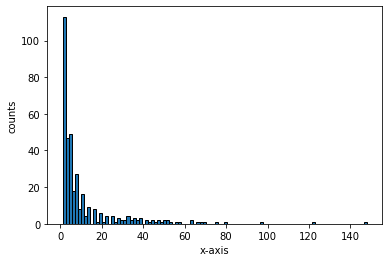

In [144]:
histogram(x2mapsNum, bins=100)

# find out which reactions are NOT linked to modules / maps

In [146]:
# missing 125 folds
# 57 modules on KEGG don't have Reactions
# rn2rules is missing 230 reactions from KEGG API (module2rxn)
len(x2modules)

274

In [147]:
# which folds are (no module) from 397?
for x in xgroup2ns.keys():
    if x not in x2modules.keys():
        print(x, x2names.get(x, "NO X NAME"), x2maps.get(x, "NO MAPS"))

911 NO X NAME NO MAPS
3847 NO X NAME NO MAPS
313 NO X NAME {'map00550', 'map01250', 'map00520'}
131 PDEase-like {'map00230', 'map01232', 'map00562', 'map00790', 'map01250', 'map00240', 'map00053'}
3997 NO X NAME {'map00860'}
69 NO X NAME {'map00230', 'map01232', 'map00240'}
708 NO X NAME {'map00680', 'map01200'}
7540 NO X NAME NO MAPS
7568 NO X NAME NO MAPS
3994 NO X NAME {'map00440'}
209 NO X NAME {'map00340'}
7549 NO X NAME {'map00240'}
6174 NO X NAME NO MAPS
4159 NO X NAME {'map00520', 'map01250'}
7589 NO X NAME NO MAPS
3005 NO X NAME {'map00230', 'map01232', 'map00240'}
3292 NO X NAME {'map00230', 'map01232'}
284 FKBP-like {'map00564'}
3599 NO X NAME {'map00640', 'map00410'}
557 NO X NAME {'map00362', 'map00624', 'map00627'}
7539 NO X NAME {'map00740', 'map00330', 'map00562'}
3892 NO X NAME {'map00760'}
623 NO X NAME {'map00561', 'map00640'}
702 NO X NAME {'map00500'}
620 NO X NAME {'map00350', 'map00340'}
3304 NO X NAME {'map00500'}
830 NO X NAME {'map00643', 'map00380', 'map00627

In [148]:
len(x2maps)  # 363 is better, but still missing 34 folds

363

In [149]:
# which folds are (no map) from 397? 
for x in xgroup2ns.keys():
    if x not in x2maps.keys():
        print(x, x2names.get(x, "NO X NAME"), x2modules.get(x, "NO MODULES"), x2ns[x], x2architecture[x])

911 NO X NAME NO MODULES 4315.0 few secondary structure elements
3847 NO X NAME NO MODULES 4315.0 alpha bundles
7540 NO X NAME NO MODULES 4315.0 a/b three-layered sandwiches
7568 NO X NAME NO MODULES 4315.0 a/b three-layered sandwiches
6174 NO X NAME NO MODULES 4314.0 alpha arrays
7589 NO X NAME NO MODULES 4311.0 a/b three-layered sandwiches
3456 NO X NAME {'M00144', 'M00147', 'M00145', 'M00146', 'M00143', 'M00142'} 4315.0 extended segments
144 NO X NAME NO MODULES 4315.0 alpha arrays
3374 NO X NAME NO MODULES 4315.0 a+b complex topology
6075 NO X NAME NO MODULES 4315.0 alpha bundles
4279 NO X NAME NO MODULES 4315.0 a+b three layers
228 NO X NAME NO MODULES 4315.0 a+b three layers
307 NO X NAME NO MODULES 4315.0 a+b two layers
324 NO X NAME NO MODULES 4315.0 a+b two layers
3076 NO X NAME NO MODULES 4312.0 alpha arrays
4114 NO X NAME NO MODULES 4315.0 a+b two layers
73 NO X NAME NO MODULES 4315.0 beta sandwiches
3579 NO X NAME {'M00144', 'M00147', 'M00145', 'M00146', 'M00143', 'M00142'}

In [150]:
# 34 - 7 = 27 are noMAPnoMODULE...
# all have ns = 4315
# the other 7 all have {'M00145', 'M00146', 'M00147', 'M00142', 'M00144', 'M00143'}
# what are these? It's all Oxydative Phosphorylation (https://www.genome.jp/pathway/map00190+M00146)

missing = {'M00145', 'M00146', 'M00147', 'M00142', 'M00144', 'M00143'}
for module in missing:
    print(modules[module])

NADH dehydrogenase (ubiquinone) 1 alpha subcomplex
NADH:quinone oxidoreductase, prokaryotes
NADH dehydrogenase (ubiquinone) 1 beta subcomplex
NADH dehydrogenase (ubiquinone) Fe-S protein/flavoprotein complex, mitochondria
NAD(P)H:quinone oxidoreductase, chloroplasts and cyanobacteria
NADH:ubiquinone oxidoreductase, mitochondria


In [151]:
# Let's manually assign 3456, 3579, 3697, 3843, 3281, 4272, 4025 to Oxydative Phosphorylation
# already exists!
# 'map00190': 'Oxidative phosphorylation

In [152]:
url = f'https://rest.kegg.jp/link/rn/map00190'
response = requests.get(url)
if response.status_code == 200:
    counter = 0
    for line in response.text.split('\n'):
        print(line)
        
# empty! it's KEGG's fault

In [153]:
# 363 + 7 = 370
oxphosX = [3456, 3579, 3697, 3843, 3281, 4272, 4025]
for x in oxphosX:
    x2maps[str(x)] = {'map00190'}

## forgotten folds (no module, no map)

In [154]:
# which folds are (no map) from 397? 
forgottenX = set()
for x in xgroup2ns.keys():
    if x not in x2maps.keys():
        print(f'X{x}, #rxn={len(x2rxn[x])}, {x2ns[x]}, {x2names.get(x, "NO X NAME")}, {x2modules.get(x, "NO MODULES")}, {x2architecture[x]}')
        forgottenX.add(x)

X911, #rxn=2, 4315.0, NO X NAME, NO MODULES, few secondary structure elements
X3847, #rxn=3, 4315.0, NO X NAME, NO MODULES, alpha bundles
X7540, #rxn=3, 4315.0, NO X NAME, NO MODULES, a/b three-layered sandwiches
X7568, #rxn=8, 4315.0, NO X NAME, NO MODULES, a/b three-layered sandwiches
X6174, #rxn=4, 4314.0, NO X NAME, NO MODULES, alpha arrays
X7589, #rxn=5, 4311.0, NO X NAME, NO MODULES, a/b three-layered sandwiches
X144, #rxn=2, 4315.0, NO X NAME, NO MODULES, alpha arrays
X3374, #rxn=2, 4315.0, NO X NAME, NO MODULES, a+b complex topology
X6075, #rxn=4, 4315.0, NO X NAME, NO MODULES, alpha bundles
X4279, #rxn=4, 4315.0, NO X NAME, NO MODULES, a+b three layers
X228, #rxn=5, 4315.0, NO X NAME, NO MODULES, a+b three layers
X307, #rxn=3, 4315.0, NO X NAME, NO MODULES, a+b two layers
X324, #rxn=2, 4315.0, NO X NAME, NO MODULES, a+b two layers
X3076, #rxn=2, 4312.0, NO X NAME, NO MODULES, alpha arrays
X4114, #rxn=5, 4315.0, NO X NAME, NO MODULES, a+b two layers
X73, #rxn=16, 4315.0, NO X N

In [155]:
len(forgottenX)

27

In [156]:
print(forgottenX)

{'324', '7556', '7589', '196', '3076', '7540', '911', '3371', '3960', '6174', '106', '581', '307', '4024', '3752', '1144', '3847', '144', '228', '73', '6075', '4046', '7568', '3374', '4279', '4114', '285'}


In [157]:
for x in forgottenX:
    print(x, x2AbsReqModules.get(x, "N/A"), x2rxn[x], x in singleModuleXset)

324 N/A ['R12602', 'R12603'] False
7556 N/A ['R00019', 'R07181', 'R09508', 'R07181_v1', 'R00019_v1', 'R07181_v2'] False
7589 N/A ['R11784', 'R11803', 'R11706', 'R11707', 'R12616'] False
196 N/A ['R02903', 'R03274', 'R10484'] False
3076 N/A ['R09675', 'R09675_v1'] False
7540 N/A ['R12098', 'R09637', 'R09639'] False
911 N/A ['R09502', 'R09502_v1'] False
3371 N/A ['R00164', 'R00164_v3', 'R00164_v4', 'R00164_v5', 'R00164_v2', 'R00164_v1'] False
3960 N/A ['R02226', 'R01889'] False
6174 N/A ['R09572', 'R11594', 'R09572_v1', 'R11594_v1'] False
106 N/A ['R08057', 'R05724', 'R05725', 'R08057_v1', 'R05724_v1', 'R08057_v2', 'R05725_v1'] False
581 N/A ['R00019', 'R07181', 'R07181_v1', 'R00019_v1', 'R07181_v2'] False
307 N/A ['R07651', 'R07651_v2', 'R07651_v1'] False
4024 N/A ['R09095', 'R04015', 'R02965', 'R07182', 'R04015_v3', 'R04015_v1', 'R09095_v1', 'R04015_v2', 'R02965_v1'] False
3752 N/A ['R07598', 'R07598_v1'] False
1144 N/A ['R05735', 'R05735_v1'] False
3847 N/A ['R01810', 'R08600', 'R0860

In [158]:
# just to check...
for x in forgottenX:
    for r in x2rxn[x]:
        print(rxn2map.get(r, "NO MAP"), rxn2module.get(r, "NO MODULE"))

NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODULE
NO MAP NO MODU

# let's add maps to ArcBacEuk only folds analysis

In [159]:
# archaea only
for x in a_only:
    print('------------------------')
    print('------------------------')
    print(f"X{x}, {x2names.get(x, 'NO NAME')}, {x2architecture[x]}")
    
    module_list = x2modules.get(x, 0)
    if module_list != 0:
        for module in x2modules.get(x, 0):
            print(module, modules[module])
    else:
        print('NO MODULE')
            
    map_list = x2maps.get(x, 0)
    if map_list != 0:
        for mapname in x2maps.get(x, 0):
            print(mapname, map2description[mapname])
    
    else:
        print('NO MAP')
    reactions = x2rxn[x]
    for rxn in reactions:
        print(rxn, rn2rules[rxn])

------------------------
------------------------
X5103, NO NAME, a/b three-layered sandwiches
NO MODULE
map00270 Cysteine and methionine metabolism
R12342 {frozenset({'5103', '876'})}


In [160]:
a_only = {'5103'}
b_only = {'4036', '4035', '914', '3018', '582', '6051', '3339', '4054', '640', '6113', '1055', '3847', '6174'}
e_only = {'3322', '3257', '558', '3777', '3371'}
first10 = {'325', '2002', '218', '206', '4953', '2003', '2007', '602', '2005', '4952'}
group1set = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}
aux = {'3323', '806', '197', '3686', '3692', '4046', '7578', '7536', '7546', '7572', '3304', '3257', '3018', '525', '4081', '873', '66', '3687', '4033', '4029', '914', '196', '4076', '4024', '3456', '7500', '218', '3697', '3960', '387', '3752', '632', '3699', '7587', '7604', '275', '3264', '4028', '4011', '7540', '1077', '7518', '3994', '3777', '4971', '3292', '7', '4', '258', '3691', '214', '1114', '3843', '557', '279', '6051', '3117', '64', '3281', '1143', '3847', '148', '1144', '2496', '177', '6058', '253', '3858', '4017', '558', '2493', '3001', '187', '4004', '581', '7568', '3374', '296', '3052', '4018', '103', '3685', '4025', '872', '4952', '4223', '5067', '313', '7602', '376', '4048', '4262', '4335', '3500', '865', '3115', '7563', '4044', '147', '7521', '3892', '6166', '6174', '4036', '5100', '4035', '4022', '640', '3269', '7522', '3339', '602', '3294', '6096', '192', '169', '3599', '75', '228', '3688', '805', '179', '3623', '3651', '6113', '603', '4159', '6075', '7601', '623', '6094', '7554', '4178', '189', '3005', '3993', '4002', '2008', '284', '1137', '5103', '881', '702', '4294', '4272', '3322', '7556', '1055', '503', '377', '7595', '629', '270', '144', '4020', '199', '102', '4054', '4045', '7507', '4953', '920', '184', '3997', '277', '154', '69', '611', '4161', '1074', '1001', '355', '3579', '4995', '378', '3321', '3654', '3794', '812', '4049', '106', '7544', '590', '268'}
arua = {'1055', '136', '158', '185', '199', '2010', '239', '270', '3001', '3052', '309', '3115', '319', '3688', '374', '3754', '3896', '4004', '4019', '4022', '4028', '4048', '4076', '4110', '4126', '4160', '4237', '4295', '5084', '528', '582', '590', '6051', '6096', '640', '7513', '7551', '7553', '7567', '842', '869', '875', '876', '9'}
forgotten = {'307', '4279', '4046', '3371', '7556', '4114', '3847', '6174', '1144', '144', '324', '196', '3076', '4024', '3960', '3752', '285', '581', '7568', '3374', '228', '7540', '73', '911', '6075', '7589', '106'}

def getXinfo(x):
    group = 'group2'
    indepOrAux = 'indep'
    aruaX = ''
    only = ''
    mapping = ''
    
    if x in group1set:
        group = 'group1'
    if x in first10:
        group = 'first10'
    if x in aux:
        indepOrAux = 'aux'
    if x in arua:
        aruaX = ' |arua'
    if x in a_only:
        only = ' |a_only'
    if x in b_only:
        only = ' |b_only'
    if x in e_only:
        only = ' |e_only'
    if x in forgotten:
        mapping = ' |forgotten'
    
    
    print(f'X{x} |ds_a/b/e= {round(xgroup2ds_a[x], 2)} {round(xgroup2ds_b[x], 2)} {round(xgroup2ds_e[x], 2)} |fo={round(x2foAveNONE[x],2)} |ns={int(x2ns[x])} |#rxn={len(x2rxn[x])} |{group} |{indepOrAux} |Xname={x2names.get(x, "N/A")}{aruaX}{only}{mapping}')

In [161]:
getXinfo('876')
print(x2modules['876'], modules[next(iter(x2modules['876']))])
getXinfo('5103')

X876 |ds_a/b/e= 0.09 0.82 0.35 |fo=239.34 |ns=4315 |#rxn=2 |group2 |indep |Xname=N/A |arua
{'M00875'} Staphyloferrin B biosynthesis, L-serine => staphyloferrin B
X5103 |ds_a/b/e= 0.04 0.0 0.0 |fo=256.71 |ns=4315 |#rxn=1 |group2 |aux |Xname=N/A |a_only


In [162]:
x2rxn['876'], x2rxn['5103']

(['R12344', 'R12342'], ['R12342'])

In [163]:
# bacteria only
for x in b_only:
    print('------------------------')
    print('------------------------')
    print(f"X{x}, {x2names.get(x, 'NO NAME')}, {x2architecture[x]}")
    
    module_list = x2modules.get(x, 0)
    if module_list != 0:
        for module in x2modules.get(x, 0):
            print(module, modules[module])
    else:
        print('NO MODULE')
            
    map_list = x2maps.get(x, 0)
    if map_list != 0:
        for mapname in x2maps.get(x, 0):
            print(mapname, map2description[mapname])
    
    else:
        print('NO MAP')
#     reactions = x2rxn[x]
#     for rxn in reactions:
#         print(rxn, rn2rules[rxn])

------------------------
------------------------
X4036, NO NAME, a+b two layers
NO MODULE
map00230 Purine metabolism
------------------------
------------------------
X4035, NO NAME, a+b three layers
NO MODULE
map00230 Purine metabolism
------------------------
------------------------
X3339, NO NAME, alpha bundles
NO MODULE
map00500 Starch and sucrose metabolism
------------------------
------------------------
X640, Methane monooxygenase hydrolase gamma subunit-like, alpha arrays
M00174 Methane oxidation, methanotroph, methane => formaldehyde
map01220 Degradation of aromatic compounds
map00680 Methane metabolism
map00625 Chloroalkane and chloroalkene degradation
map01200 Carbon metabolism
map00650 Butanoate metabolism
------------------------
------------------------
X3018, NO NAME, a+b two layers
NO MODULE
map00230 Purine metabolism
map01232 Nucleotide metabolism
------------------------
------------------------
X582, NO NAME, extended segments
M00174 Methane oxidation, methanotrop

In [164]:
# eukaryotes only
for x in e_only:
    print('------------------------')
    print('------------------------')
    print(f"X{x}, {x2names.get(x, 'NO NAME')}, {x2architecture[x]}")
    
    module_list = x2modules.get(x, 0)
    if module_list != 0:
        for module in x2modules.get(x, 0):
            print(module, modules[module])
    else:
        print('NO MODULE')
            
    map_list = x2maps.get(x, 0)
    if map_list != 0:
        for mapname in x2maps.get(x, 0):
            print(mapname, map2description[mapname])
    
    else:
        print('NO MAP')
#     reactions = x2rxn[x]
#     for rxn in reactions:
#         print(rxn, rn2rules[rxn])

------------------------
------------------------
X3371, NO NAME, few secondary structure elements
NO MODULE
NO MAP
------------------------
------------------------
X3777, NO NAME, alpha bundles
NO MODULE
map00330 Arginine and proline metabolism
------------------------
------------------------
X3257, NO NAME, a+b complex topology
NO MODULE
map00562 Inositol phosphate metabolism
------------------------
------------------------
X3322, NO NAME, alpha bundles
M00083 Fatty acid biosynthesis, elongation
M00082 Fatty acid biosynthesis, initiation
map01212 Fatty acid metabolism
map00061 Fatty acid biosynthesis
------------------------
------------------------
X558, NO NAME, alpha duplicates or obligate multimers
NO MODULE
map00565 Ether lipid metabolism


## one "issue" with maps - hard to tell if something is abs.req. or not!

In [165]:
map2description['map00300']

'Lysine biosynthesis'

In [166]:
# absolutely required AND uniquely associated
for x in arua:
    print(f'X{x} ({x2names.get(x, "NO X NAME")})')
    for module in x2modules[x]:
        print(f'{module}: {modules[module]}')
    for mapname in x2maps[x]:
        print(f'{mapname}: {map2description[mapname]}')
    print('-----------------------------------')

X3052 (NO X NAME)
M00880: Molybdenum cofactor biosynthesis, GTP => molybdenum cofactor
map00790: Folate biosynthesis
map01240: Biosynthesis of cofactors
-----------------------------------
X875 (NO X NAME)
M00022: Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
map00400: Phenylalanine, tyrosine and tryptophan biosynthesis
map01230: Biosynthesis of amino acids
-----------------------------------
X4028 (NO X NAME)
M00532: Photorespiration
map01200: Carbon metabolism
map00630: Glyoxylate and dicarboxylate metabolism
map00380: Tryptophan metabolism
-----------------------------------
X4022 (NO X NAME)
M00045: Histidine degradation, histidine => N-formiminoglutamate => glutamate
map00340: Histidine metabolism
-----------------------------------
X582 (NO X NAME)
M00174: Methane oxidation, methanotroph, methane => formaldehyde
map00680: Methane metabolism
map00010: Glycolysis / Gluconeogenesis
map00625: Chloroalkane and chloroalkene degradation
map01200: Carbon metabolism


In [167]:
x2modules

{'7553': {'M00122'},
 '2487': {'M00009',
  'M00010',
  'M00011',
  'M00012',
  'M00029',
  'M00030',
  'M00038',
  'M00051',
  'M00169',
  'M00171',
  'M00172',
  'M00173',
  'M00345',
  'M00374',
  'M00376',
  'M00432',
  'M00433',
  'M00535',
  'M00580',
  'M00608',
  'M00620',
  'M00740',
  'M00778',
  'M00837',
  'M00838',
  'M00889',
  'M00912'},
 '147': {'M00009', 'M00011', 'M00032', 'M00036', 'M00307'},
 '2011': {'M00016',
  'M00028',
  'M00031',
  'M00034',
  'M00045',
  'M00525',
  'M00609',
  'M00763',
  'M00845',
  'M00879',
  'M00889',
  'M00919',
  'M00930',
  'M00931',
  'M00958',
  'M00959',
  'M00968'},
 '4048': {'M00532'},
 '136': {'M00043'},
 '2493': {'M00060', 'M00357', 'M00579'},
 '4004': {'M00100'},
 '217': {'M00009',
  'M00011',
  'M00039',
  'M00101',
  'M00114',
  'M00129',
  'M00309',
  'M00372',
  'M00532',
  'M00546',
  'M00810',
  'M00894',
  'M00901',
  'M00917',
  'M00945',
  'M00946',
  'M00958',
  'M00959'},
 '210': {'M00048', 'M00099', 'M00672', 'M00675

In [168]:
print(x2names['109'], x2architecture['109'])
print(x2names['148'], x2architecture['109'])
print(x2names['2004'], x2architecture['109'])
print(x2names['2007'], x2architecture['109'])
print(x2names.get('3997', 'NONE'), x2architecture['109'] )

Repetitive alpha hairpins alpha superhelices
Histone-like alpha superhelices
P-loop domains-like alpha superhelices
Flavodoxin-like alpha superhelices
NONE alpha superhelices


In [169]:
x2maps['3997']

{'map00860'}

In [170]:
for x in arua:
    print(f'X{x} ({x2names.get(x, "NO X NAME")}) {list(x2modules[x])[0]}: {modules[list(x2modules[x])[0]]}')
    print(len(x2rxn[x]))
    for mapname in x2maps[x]:
        print(mapname, map2description[mapname])
    print('-----------------------------------------')

X3052 (NO X NAME) M00880: Molybdenum cofactor biosynthesis, GTP => molybdenum cofactor
8
map00790 Folate biosynthesis
map01240 Biosynthesis of cofactors
-----------------------------------------
X875 (NO X NAME) M00022: Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
2
map00400 Phenylalanine, tyrosine and tryptophan biosynthesis
map01230 Biosynthesis of amino acids
-----------------------------------------
X4028 (NO X NAME) M00532: Photorespiration
5
map01200 Carbon metabolism
map00630 Glyoxylate and dicarboxylate metabolism
map00380 Tryptophan metabolism
-----------------------------------------
X4022 (NO X NAME) M00045: Histidine degradation, histidine => N-formiminoglutamate => glutamate
2
map00340 Histidine metabolism
-----------------------------------------
X582 (NO X NAME) M00174: Methane oxidation, methanotroph, methane => formaldehyde
8
map00680 Methane metabolism
map00010 Glycolysis / Gluconeogenesis
map00625 Chloroalkane and chloroalkene degradation
map01

## Liam: check X302 and X304

In [171]:
x2names['302']

'Reverse ferredoxin'

In [172]:
x2names['304']

'Alpha-beta plaits'

In [173]:
x2rxn['302']

['R00024',
 'R03140',
 'R05453',
 'R05735',
 'R05735_v1',
 'R05453_v1',
 'R03140_v1',
 'R00024_v1']

In [174]:
'304' in arSet

True

In [175]:
# get reaction info
for r in x2rxn['302']:

    url = f'https://rest.kegg.jp/get/{r}'
    response = requests.get(url)
    
    if response.status_code == 200:
        # Print the content of the response
        print(response.text)
        print('---------------------------------')
    else:
        print(f"Error: {response.status_code}")

ENTRY       R00024                      Reaction
NAME        3-phospho-D-glycerate carboxy-lyase (dimerizing; D-ribulose-1,5-bisphosphate-forming)
DEFINITION  D-Ribulose 1,5-bisphosphate + CO2 + H2O <=> 2 3-Phospho-D-glycerate
EQUATION    C01182 + C00011 + C00001 <=> 2 C00197
COMMENT     multi-step reaction (isomerization, carboxylation, hydration and cleavage)
RCLASS      RC00172  C00197_C01182
ENZYME      4.1.1.39
PATHWAY     rn00710  Carbon fixation in photosynthetic organisms
            rn01100  Metabolic pathways
            rn01120  Microbial metabolism in diverse environments
            rn01200  Carbon metabolism
MODULE      M00165  Reductive pentose phosphate cycle (Calvin cycle)
BRITE       Enzymatic reactions [BR:br08201]
             4. Lyase reactions
              4.1  Carbon-carbon lyases
               4.1.1  Carboxy-lyases
                4.1.1.39
                 R00024  D-Ribulose 1,5-bisphosphate + CO2 + H2O <=> 2 3-Phospho-D-glycerate
            Overall reaction 

# checking the new "couple" 184 & 7544

In [176]:
x2rxn['7544']  # "NO_X_NAME"	"NO_H_NAME"	"Nucleoside phosphorylase/phosphoribosyltransferase catalytic domain"

['R00985',
 'R00986',
 'R01073',
 'R08222',
 'R10836',
 'R10837',
 'R10838',
 'R08230',
 'R01570',
 'R01876',
 'R02296',
 'R02484',
 'R02298',
 'R00985_v1',
 'R02296_v1',
 'R01073_v1',
 'R02484_v1',
 'R01570_v1',
 'R02298_v1',
 'R00986_v1',
 'R01876_v1']

In [177]:
x2rxn['184']  # "NO_X_NAME"	"NO_H_NAME"	"Nucleoside phosphorylase/phosphoribosyltransferase-N"

['R00985',
 'R00986',
 'R01073',
 'R08222',
 'R10836',
 'R10837',
 'R10838',
 'R08230',
 'R01570',
 'R01876',
 'R02296',
 'R02484',
 'R02298',
 'R00985_v1',
 'R02296_v1',
 'R01073_v1',
 'R02484_v1',
 'R01570_v1',
 'R02298_v1',
 'R00986_v1',
 'R01876_v1']

In [178]:
x2rxn['184'] == x2rxn['7544']

True

In [179]:
x2ns['184'], x2ns['7544']

(3069.0, 3069.0)

In [180]:
# get reaction info
for r in x2rxn['184']:

    url = f'https://rest.kegg.jp/get/{r}'
    response = requests.get(url)
    
    if response.status_code == 200:
        # Print the content of the response
        print(response.text)
    else:
        print(f"Error: {response.status_code}")

ENTRY       R00985                      Reaction
NAME        chorismate pyruvate-lyase (amino-accepting; anthranilate-forming)
DEFINITION  Chorismate + Ammonia <=> Anthranilate + Pyruvate + H2O
EQUATION    C00251 + C00014 <=> C00108 + C00022 + C00001
RCLASS      RC02148  C00022_C00251
            RC02414  C00108_C00251
ENZYME      4.1.3.27
PATHWAY     rn00400  Phenylalanine, tyrosine and tryptophan biosynthesis
            rn01100  Metabolic pathways
            rn01110  Biosynthesis of secondary metabolites
            rn01230  Biosynthesis of amino acids
MODULE      M00023  Tryptophan biosynthesis, chorismate => tryptophan
BRITE       Enzymatic reactions [BR:br08201]
             4. Lyase reactions
              4.1  Carbon-carbon lyases
               4.1.3  Oxo-acid-lyases
                4.1.3.27
                 R00985  Chorismate + Ammonia <=> Anthranilate + Pyruvate + H2O
ORTHOLOGY   K01656  anthranilate synthase / indole-3-glycerol phosphate synthase [EC:4.1.3.27 4.1.1.48]
   

ENTRY       R08230                      Reaction
NAME        5-fluorodeoxyuridine:phosphate deoxy-alpha-D-ribosyltransferase
DEFINITION  5-FU + 2-Deoxy-D-ribose 1-phosphate <=> 5-Fluorodeoxyuridine + Orthophosphate
EQUATION    C07649 + C00672 <=> C11736 + C00009
RCLASS      RC00063  C07649_C11736
ENZYME      2.4.2.4
PATHWAY     rn00983  Drug metabolism - other enzymes
BRITE       Enzymatic reactions [BR:br08201]
             2. Transferase reactions
              2.4  Glycosyltransferases
               2.4.2  Pentosyltransferases
                2.4.2.4
                 R08230  5-FU + 2-Deoxy-D-ribose 1-phosphate <=> 5-Fluorodeoxyuridine + Orthophosphate
ORTHOLOGY   K00758  thymidine phosphorylase [EC:2.4.2.4]
///

ENTRY       R01570                      Reaction
NAME        thymidine:phosphate deoxy-alpha-D-ribosyltransferase
DEFINITION  Thymidine + Orthophosphate <=> Thymine + 2-Deoxy-D-ribose 1-phosphate
EQUATION    C00214 + C00009 <=> C00178 + C00672
RCLASS      RC00063  C00178_C0

In [181]:
# mostly sugar phosphate synthesis

# "fold-complexity" of different modules? (how many folds are required)

In [182]:
module2x

{'M00001': [[{'2484'}],
  [{'2484'}],
  [{'2003'}],
  [{'2007', '7572'}],
  [{'2003'}],
  [{'304'}, {'2002'}],
  [{'2002'}],
  [{'2003', '298'}],
  [{'2003', '298'}],
  [{'7532', '7533'}],
  [{'169', '806'}],
  [{'7515', '7554'}, {'304', '7515'}, {'7525'}],
  [{'2002', '218'}],
  [{'1', '7518'}]],
 'M00002': [[{'2002'}],
  [{'2003', '298'}],
  [{'2003', '298'}],
  [{'7532', '7533'}],
  [{'169', '806'}],
  [{'7515', '7554'}, {'304', '7515'}, {'7525'}],
  [{'2002', '218'}],
  [{'1', '7518'}]],
 'M00003': [[{'2004'}],
  [{'2004'}],
  [{'2004'}],
  [{'2002', '218'}],
  [{'7515', '7554'}, {'304', '7515'}, {'7525'}],
  [{'7532', '7533'}],
  [{'2003', '298'}],
  [{'2003', '298'}],
  [{'2002'}],
  [{'304'}, {'2002'}],
  [{'4018', '7587'}]],
 'M00004': [[{'2003', '298'}],
  [{'2003', '298'}, {'2003'}],
  [{'2003', '298'}, {'2003'}, {'5'}],
  [{'129', '2003'}],
  [{'129', '2003'}],
  [{'2002'}],
  [{'2003', '304'}, {'7560'}],
  [{'7522', '7574'}],
  [{'2002'}],
  [{'7522', '7574'}],
  [{'2007'},

In [183]:
test = {'M00009': [[{'172'}, {'2002'}],
  [{'109', '2487', '7542'}, {'2487', '7542'}],
  [{'109', '2487', '7542'}, {'2487', '7542'}],
  [{'109', '2487', '7542'}, {'2487', '7542'}],
  [{'7510'}],
  [{'7510'}],
  [{'7510'}],
  [{'7510'}],
  [{'7522', '7574'}, {'323', '7522', '7574'}],
  [{'7522', '7574'}, {'323', '7522', '7574'}],
  [{'7522', '7574'}, {'323', '7522', '7574'}],
  [{'147', '323', '325'}, {'323', '7522', '7574'}],
  [{'2003', '244'}],
  [{'2004', '205', '7574'}],
  [{'2003', '2007', '206'}],
  [{'2003', '2007', '206'}],
  [{'2003', '2007', '206'}],
  [{'2003'}],
  [{'187', '221', '278', '5069', '604'}],
  [{'4952', '4953', '602'}, {'2485', '2487'}],
  [{'2003', '279'}],
  [{'2003', '217', '304'}]]}

In [184]:
req_folds = set()

In [185]:
module = 'M00009'
unsolved_rules = dict()

# first, gather len(rxn) == 1
for rxn in test[module]:
    print(rxn)
    if len(rxn) == 1:  # only one rule => these folds are required
        for x in rxn[0]:
            req_folds.add(x)

# if rxn has multiple rules, check if pre-existing folds can make one of the rules:
for rxn in test[module]:
    if len(rxn) != 1:  # multiple rules

        rules = []
        skip_this_rxn = False
        
        for rule in rxn:
            if all(x in req_folds for x in rule):  # this rule can be made using req_folds => this rxn is fine!
                skip_this_rxn = True
                continue
            else:  # this rule cannot be made using req_folds
                rules.append(rule)

        if not skip_this_rxn: # no rule in this rxn can be made with req_folds
            for rule in rules:
                if frozenset(rule) not in unsolved_rules.keys():
                    unsolved_rules[frozenset(rule)] = 1
                else:
                    unsolved_rules[frozenset(rule)] += 1

print('------------------------------------')
print(f'req_folds: {req_folds}')
print(f'unsolved_rules: {unsolved_rules}')

# add the most frequent rule. if multiple ties, pick the shortest rule.
if len(unsolved_rules) != 0:
    highest_freq = max(unsolved_rules, key=unsolved_rules.get)
    print(f'highest_freq: {unsolved_rules[highest_freq]}')

    most_frequent = {}
    for key, value in unsolved_rules.items():
        if value == unsolved_rules[highest_freq]:
            most_frequent[key] = len(key)
    print(f'most_frequent: {most_frequent}')

    shortest_len = min(most_frequent, key=most_frequent.get)
    print(f'shortest_len: {most_frequent[shortest_len]}')

    for key, value in most_frequent.items():
        if value == most_frequent[shortest_len]:
            rule_to_add = key
            break

    print(f'fold(s) to add:{rule_to_add}')
    unsolved_rules.pop(rule_to_add)
    for fold in rule_to_add:
        req_folds.add(fold)
else:
    print('*** DONE! ***')
    print(f'ALL reactions in module {module} can be catalyzed with {req_folds}')
    print(f'#foldRequired={len(req_folds)}')
    total = set()
    for rxn in test[module]:
        for rule in rxn:
            for fold in rule:
                total.add(fold)
    print(f'#foldTotal={len(total)}')
    print(total - req_folds)

[{'172'}, {'2002'}]
[{'7542', '109', '2487'}, {'7542', '2487'}]
[{'7542', '109', '2487'}, {'7542', '2487'}]
[{'7542', '109', '2487'}, {'7542', '2487'}]
[{'7510'}]
[{'7510'}]
[{'7510'}]
[{'7510'}]
[{'7522', '7574'}, {'7522', '7574', '323'}]
[{'7522', '7574'}, {'7522', '7574', '323'}]
[{'7522', '7574'}, {'7522', '7574', '323'}]
[{'147', '325', '323'}, {'7522', '7574', '323'}]
[{'244', '2003'}]
[{'7574', '2004', '205'}]
[{'206', '2007', '2003'}]
[{'206', '2007', '2003'}]
[{'206', '2007', '2003'}]
[{'2003'}]
[{'278', '604', '5069', '221', '187'}]
[{'602', '4953', '4952'}, {'2487', '2485'}]
[{'2003', '279'}]
[{'217', '304', '2003'}]
------------------------------------
req_folds: {'217', '278', '304', '7510', '205', '5069', '221', '2003', '7574', '2007', '604', '206', '244', '2004', '187', '279'}
unsolved_rules: {frozenset({'172'}): 1, frozenset({'2002'}): 1, frozenset({'7542', '109', '2487'}): 3, frozenset({'7542', '2487'}): 3, frozenset({'7522', '7574'}): 3, frozenset({'7522', '7574', '32

In [186]:
def fold_complexity_loop(module, req, unsolved):
    req_folds = req
    unsolved_rules = unsolved
    
    # first, gather len(rxn) == 1
    for rxn in module2x[module]:
        if len(rxn) == 1:  # only one rule => these folds are required
            for x in rxn[0]:
                req_folds.add(x)

    # if rxn has multiple rules, check if pre-existing folds can make one of the rules:
    for rxn in module2x[module]:
        if len(rxn) != 1:  # multiple rules

            rules = []
            skip_this_rxn = False

            # check all rules in rxn
            for rule in rxn:
                if all(x in req_folds for x in rule):  # this rule can be made using req_folds => this rxn is fine!
                    skip_this_rxn = True
                    continue
                else:  # this rule cannot be made using req_folds
                    rules.append(rule)

            if not skip_this_rxn: # no rule in this rxn can be made with req_folds
                for rule in rules:
                    if frozenset(rule) not in unsolved_rules.keys():
                        unsolved_rules[frozenset(rule)] = 1
                    else:
                        unsolved_rules[frozenset(rule)] += 1
            
            else:  # skip_this_rxn = True; there is 1+ rule that can catalyze this reaction
                continue
    
    return req_folds, unsolved_rules

In [187]:
def fold_complexity(module):
    req = set()
    unsolved = dict()

    # first loop
    req_folds, unsolved_rules = fold_complexity_loop(module, req, unsolved)

    while len(unsolved_rules) != 0:
    # add the most frequent rule. if multiple ties, pick the shortest rule.
        # print(unsolved_rules)
        
        # LOOK for highest frequency
        highest_freq = max(unsolved_rules, key=unsolved_rules.get)
        # print(f'highest_freq: {unsolved_rules[highest_freq]}')

        most_frequent = {}
        for key, value in unsolved_rules.items():
            if value == unsolved_rules[highest_freq]:
                most_frequent[key] = len(key)
        # print(f'most_frequent: {most_frequent}')

        # LOOK for shortest length
        shortest_len = min(most_frequent, key=most_frequent.get)
        # print(f'shortest_len: {most_frequent[shortest_len]}')

        for key, value in most_frequent.items():
            if value == most_frequent[shortest_len]:
                rule_to_add = key
                break  # just take the first one

        # print(f'fold(s) to add:{rule_to_add}')
        # add new folds
        unsolved_rules.pop(rule_to_add)
        for fold in rule_to_add:
            req_folds.add(fold)
            
        req_folds, unsolved_rules = fold_complexity_loop(module, req_folds, dict())

    # len(unsolved_rules) == 0
    print('--------------------------------')
    print(f'ALL reactions in module {module} can be catalyzed with {req_folds}')
    print(f'#foldRequired={len(req_folds)}')
    total = set()
    for rxn in module2x[module]:
        for rule in rxn:
            for fold in rule:
                total.add(fold)
    print(f'#foldTotal={len(total)}')
    print(f'#unnecessary={total - req_folds}')
    return req_folds

In [188]:
module2reqFolds = {}
for module in module2x.keys():
    module2reqFolds[module] = fold_complexity(module)

--------------------------------
ALL reactions in module M00001 can be catalyzed with {'2484', '218', '7518', '2003', '169', '806', '1', '7533', '2002', '2007', '7532', '7525', '298', '7572'}
#foldRequired=14
#foldTotal=17
#unnecessary={'7515', '7554', '304'}
--------------------------------
ALL reactions in module M00002 can be catalyzed with {'218', '7518', '2003', '169', '806', '1', '7533', '2002', '7532', '7525', '298'}
#foldRequired=11
#foldTotal=14
#unnecessary={'7554', '7515', '304'}
--------------------------------
ALL reactions in module M00003 can be catalyzed with {'218', '2003', '7533', '7525', '4018', '2002', '7532', '2004', '298', '7587'}
#foldRequired=10
#foldTotal=13
#unnecessary={'7554', '7515', '304'}
--------------------------------
ALL reactions in module M00004 can be catalyzed with {'7522', '2003', '7574', '129', '2002', '7560', '298'}
#foldRequired=7
#foldTotal=11
#unnecessary={'5', '304', '2007', '10'}
--------------------------------
ALL reactions in module M00

ALL reactions in module M00572 can be catalyzed with {'222', '7579', '2003', '7581'}
#foldRequired=4
#foldTotal=4
#unnecessary=set()
--------------------------------
ALL reactions in module M00573 can be catalyzed with {'1119', '3016', '7577', '149', '2002', '2004'}
#foldRequired=6
#foldTotal=6
#unnecessary=set()
--------------------------------
ALL reactions in module M00574 can be catalyzed with set()
#foldRequired=0
#foldTotal=0
#unnecessary=set()
--------------------------------
ALL reactions in module M00575 can be catalyzed with set()
#foldRequired=0
#foldTotal=0
#unnecessary=set()
--------------------------------
ALL reactions in module M00576 can be catalyzed with set()
#foldRequired=0
#foldTotal=0
#unnecessary=set()
--------------------------------
ALL reactions in module M00577 can be catalyzed with {'1119', '3016', '7577', '2002', '2004'}
#foldRequired=5
#foldTotal=5
#unnecessary=set()
--------------------------------
ALL reactions in module M00579 can be catalyzed with {'1'

#foldRequired=0
#foldTotal=0
#unnecessary=set()
--------------------------------
ALL reactions in module M00746 can be catalyzed with set()
#foldRequired=0
#foldTotal=0
#unnecessary=set()
--------------------------------
ALL reactions in module M00761 can be catalyzed with {'3016', '7577', '2003', '270', '2002', '7571', '7516'}
#foldRequired=7
#foldTotal=7
#unnecessary=set()
--------------------------------
ALL reactions in module M00763 can be catalyzed with {'304', '2011', '3016', '7577', '2003', '7531', '206', '298'}
#foldRequired=8
#foldTotal=8
#unnecessary=set()
--------------------------------
ALL reactions in module M00769 can be catalyzed with set()
#foldRequired=0
#foldTotal=0
#unnecessary=set()
--------------------------------
ALL reactions in module M00773 can be catalyzed with {'304', '6094', '236', '268', '149', '222', '7512', '2003', '7581'}
#foldRequired=9
#foldTotal=9
#unnecessary=set()
--------------------------------
ALL reactions in module M00774 can be catalyzed wit

In [189]:
module2reqFolds

{'M00001': {'1',
  '169',
  '2002',
  '2003',
  '2007',
  '218',
  '2484',
  '298',
  '7518',
  '7525',
  '7532',
  '7533',
  '7572',
  '806'},
 'M00002': {'1',
  '169',
  '2002',
  '2003',
  '218',
  '298',
  '7518',
  '7525',
  '7532',
  '7533',
  '806'},
 'M00003': {'2002',
  '2003',
  '2004',
  '218',
  '298',
  '4018',
  '7525',
  '7532',
  '7533',
  '7587'},
 'M00004': {'129', '2002', '2003', '298', '7522', '7560', '7574'},
 'M00005': {'7573'},
 'M00006': {'129', '2003', '298'},
 'M00007': {'2002', '7522', '7560', '7574'},
 'M00008': {'2002', '2003', '298'},
 'M00009': {'172',
  '187',
  '2003',
  '2004',
  '2007',
  '205',
  '206',
  '217',
  '221',
  '244',
  '2485',
  '2487',
  '278',
  '279',
  '304',
  '323',
  '5069',
  '604',
  '7510',
  '7522',
  '7542',
  '7574'},
 'M00010': {'172', '2487', '7510', '7542'},
 'M00011': {'187',
  '2003',
  '2004',
  '2007',
  '205',
  '206',
  '217',
  '221',
  '244',
  '2485',
  '2487',
  '278',
  '279',
  '304',
  '323',
  '5069',
  '604

In [190]:
module2reqFoldsNum = {}
for mod in module2reqFolds.keys():
    module2reqFoldsNum[mod] = len(module2reqFolds[mod])

In [191]:
module2reqFoldsNum

{'M00001': 14,
 'M00002': 11,
 'M00003': 10,
 'M00004': 7,
 'M00005': 1,
 'M00006': 3,
 'M00007': 4,
 'M00008': 3,
 'M00009': 22,
 'M00010': 4,
 'M00011': 19,
 'M00012': 5,
 'M00013': 7,
 'M00014': 8,
 'M00015': 7,
 'M00016': 12,
 'M00017': 7,
 'M00018': 4,
 'M00019': 7,
 'M00020': 5,
 'M00021': 2,
 'M00022': 7,
 'M00023': 6,
 'M00024': 5,
 'M00025': 4,
 'M00026': 10,
 'M00027': 3,
 'M00028': 9,
 'M00029': 11,
 'M00030': 12,
 'M00031': 8,
 'M00032': 17,
 'M00033': 8,
 'M00034': 14,
 'M00035': 2,
 'M00036': 15,
 'M00037': 6,
 'M00038': 8,
 'M00039': 12,
 'M00040': 6,
 'M00042': 8,
 'M00043': 2,
 'M00044': 10,
 'M00045': 10,
 'M00046': 6,
 'M00047': 6,
 'M00048': 13,
 'M00049': 6,
 'M00050': 6,
 'M00051': 8,
 'M00052': 3,
 'M00053': 5,
 'M00055': 9,
 'M00056': 2,
 'M00057': 2,
 'M00058': 1,
 'M00059': 1,
 'M00060': 8,
 'M00061': 3,
 'M00063': 5,
 'M00064': 4,
 'M00065': 9,
 'M00066': 1,
 'M00067': 2,
 'M00068': 2,
 'M00069': 1,
 'M00070': 1,
 'M00071': 1,
 'M00072': 5,
 'M00073': 4,
 'M0

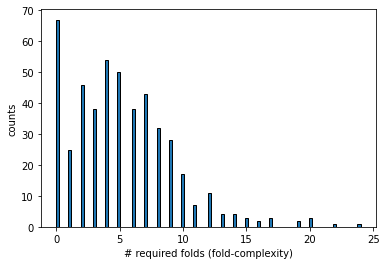

In [192]:
histogram(module2reqFoldsNum, x_axis='# required folds (fold-complexity)', bins=100)

## simple version

In [193]:
module2x['M00009']

[[{'172'}, {'2002'}],
 [{'2487', '7542'}, {'109', '2487', '7542'}],
 [{'2487', '7542'}, {'109', '2487', '7542'}],
 [{'2487', '7542'}, {'109', '2487', '7542'}],
 [{'7510'}],
 [{'7510'}],
 [{'7510'}],
 [{'7510'}],
 [{'323', '7522', '7574'}, {'7522', '7574'}],
 [{'323', '7522', '7574'}, {'7522', '7574'}],
 [{'323', '7522', '7574'}, {'7522', '7574'}],
 [{'323', '7522', '7574'}, {'147', '323', '325'}],
 [{'2003', '244'}],
 [{'2004', '205', '7574'}],
 [{'2003', '2007', '206'}],
 [{'2003', '2007', '206'}],
 [{'2003', '2007', '206'}],
 [{'2003'}],
 [{'187', '221', '278', '5069', '604'}],
 [{'4952', '4953', '602'}, {'2485', '2487'}],
 [{'2003', '279'}],
 [{'2003', '217', '304'}]]

In [194]:
def fold_complexitySIMPLE(module):
    req_folds = set()
    for rxn in module2x[module]:
        for rule in rxn:
            for x in rule:
                req_folds.add(x)
    return req_folds

In [195]:
fold_complexitySIMPLE('M00009')

{'109',
 '147',
 '172',
 '187',
 '2002',
 '2003',
 '2004',
 '2007',
 '205',
 '206',
 '217',
 '221',
 '244',
 '2485',
 '2487',
 '278',
 '279',
 '304',
 '323',
 '325',
 '4952',
 '4953',
 '5069',
 '602',
 '604',
 '7510',
 '7522',
 '7542',
 '7574'}

In [196]:
module2reqFoldsSIMPLE = {}
for module in module2x.keys():
    module2reqFoldsSIMPLE[module] = fold_complexitySIMPLE(module)

In [197]:
module2reqFoldsSIMPLE

{'M00001': {'1',
  '169',
  '2002',
  '2003',
  '2007',
  '218',
  '2484',
  '298',
  '304',
  '7515',
  '7518',
  '7525',
  '7532',
  '7533',
  '7554',
  '7572',
  '806'},
 'M00002': {'1',
  '169',
  '2002',
  '2003',
  '218',
  '298',
  '304',
  '7515',
  '7518',
  '7525',
  '7532',
  '7533',
  '7554',
  '806'},
 'M00003': {'2002',
  '2003',
  '2004',
  '218',
  '298',
  '304',
  '4018',
  '7515',
  '7525',
  '7532',
  '7533',
  '7554',
  '7587'},
 'M00004': {'10',
  '129',
  '2002',
  '2003',
  '2007',
  '298',
  '304',
  '5',
  '7522',
  '7560',
  '7574'},
 'M00005': {'7573'},
 'M00006': {'129', '2003', '298', '5'},
 'M00007': {'2002', '2003', '304', '7522', '7560', '7574'},
 'M00008': {'2002', '2003', '298', '5'},
 'M00009': {'109',
  '147',
  '172',
  '187',
  '2002',
  '2003',
  '2004',
  '2007',
  '205',
  '206',
  '217',
  '221',
  '244',
  '2485',
  '2487',
  '278',
  '279',
  '304',
  '323',
  '325',
  '4952',
  '4953',
  '5069',
  '602',
  '604',
  '7510',
  '7522',
  '7542

In [198]:
module2reqFoldsNumSIMPLE = {}
for mod in module2reqFoldsSIMPLE.keys():
    module2reqFoldsNumSIMPLE[mod] = len(module2reqFoldsSIMPLE[mod])

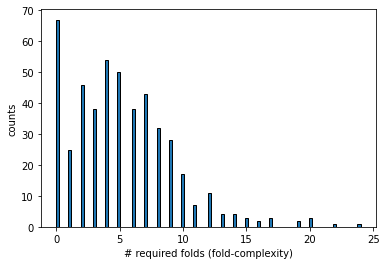

In [199]:
histogram(module2reqFoldsNum, x_axis='# required folds (fold-complexity)', bins=100)

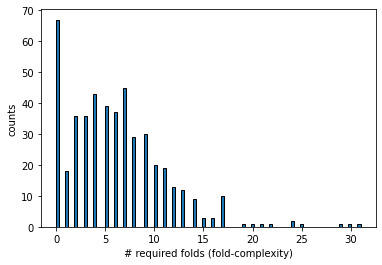

In [200]:
histogram(module2reqFoldsNumSIMPLE, x_axis='# required folds (fold-complexity)', bins=100)

In [201]:
# Top 10 complex modules?
for key, value in module2reqFoldsNumSIMPLE.items():
    if value > 18:
        print(key, value, modules[key])

M00009 29 Citrate cycle (TCA cycle, Krebs cycle)
M00011 24 Citrate cycle, second carbon oxidation, 2-oxoglutarate => oxaloacetate
M00082 19 Fatty acid biosynthesis, initiation
M00173 25 Reductive citrate cycle (Arnon-Buchanan cycle)
M00357 22 Methanogenesis, acetate => methane
M00374 31 Dicarboxylate-hydroxybutyrate cycle
M00375 24 Hydroxypropionate-hydroxybutylate cycle
M00376 30 3-Hydroxypropionate bi-cycle
M00377 20 Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)
M00620 21 Incomplete reductive citrate cycle, acetyl-CoA => oxoglutarate


In [202]:
# Top 10 complex modules (reduced)?
for key, value in module2reqFoldsNum.items():
    if value > 18:
        print(f"#folds={value} {key}: {modules[key]}")

#folds=22 M00009: Citrate cycle (TCA cycle, Krebs cycle)
#folds=19 M00011: Citrate cycle, second carbon oxidation, 2-oxoglutarate => oxaloacetate
#folds=20 M00173: Reductive citrate cycle (Arnon-Buchanan cycle)
#folds=20 M00357: Methanogenesis, acetate => methane
#folds=24 M00374: Dicarboxylate-hydroxybutyrate cycle
#folds=20 M00376: 3-Hydroxypropionate bi-cycle
#folds=19 M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)


### normalize with #rxn

In [203]:
module2reqFoldsNumSIMPLE

{'M00001': 17,
 'M00002': 14,
 'M00003': 13,
 'M00004': 11,
 'M00005': 1,
 'M00006': 4,
 'M00007': 6,
 'M00008': 4,
 'M00009': 29,
 'M00010': 6,
 'M00011': 24,
 'M00012': 7,
 'M00013': 12,
 'M00014': 9,
 'M00015': 8,
 'M00016': 12,
 'M00017': 12,
 'M00018': 9,
 'M00019': 7,
 'M00020': 6,
 'M00021': 7,
 'M00022': 10,
 'M00023': 6,
 'M00024': 7,
 'M00025': 9,
 'M00026': 13,
 'M00027': 3,
 'M00028': 12,
 'M00029': 12,
 'M00030': 13,
 'M00031': 8,
 'M00032': 17,
 'M00033': 10,
 'M00034': 14,
 'M00035': 5,
 'M00036': 15,
 'M00037': 7,
 'M00038': 10,
 'M00039': 13,
 'M00040': 10,
 'M00042': 8,
 'M00043': 2,
 'M00044': 10,
 'M00045': 11,
 'M00046': 7,
 'M00047': 6,
 'M00048': 15,
 'M00049': 6,
 'M00050': 6,
 'M00051': 11,
 'M00052': 4,
 'M00053': 7,
 'M00055': 9,
 'M00056': 2,
 'M00057': 2,
 'M00058': 1,
 'M00059': 1,
 'M00060': 9,
 'M00061': 4,
 'M00063': 5,
 'M00064': 4,
 'M00065': 9,
 'M00066': 1,
 'M00067': 2,
 'M00068': 2,
 'M00069': 1,
 'M00070': 1,
 'M00071': 1,
 'M00072': 5,
 'M00073'

In [204]:
module2reqFoldsNumSIMPLEnormalized = {}
for key, value in module2reqFoldsNumSIMPLE.items():
    if value != 0:
        module2reqFoldsNumSIMPLEnormalized[key] = value / len(module2rxn[key])
    else:
        module2reqFoldsNumSIMPLEnormalized[key] = 0

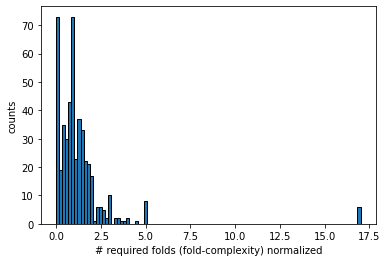

In [205]:
histogram(module2reqFoldsNumSIMPLEnormalized, x_axis='# required folds (fold-complexity) normalized', bins=100)

In [206]:
for key, value in module2reqFoldsNumSIMPLEnormalized.items():
    if value > 4:
        print(f"#folds={value} {key}: {modules[key]}")

#folds=5.0 M00072: N-glycosylation by oligosaccharyltransferase
#folds=17.0 M00142: NADH:ubiquinone oxidoreductase, mitochondria
#folds=17.0 M00143: NADH dehydrogenase (ubiquinone) Fe-S protein/flavoprotein complex, mitochondria
#folds=17.0 M00144: NADH:quinone oxidoreductase, prokaryotes
#folds=17.0 M00145: NAD(P)H:quinone oxidoreductase, chloroplasts and cyanobacteria
#folds=17.0 M00146: NADH dehydrogenase (ubiquinone) 1 alpha subcomplex
#folds=17.0 M00147: NADH dehydrogenase (ubiquinone) 1 beta subcomplex
#folds=5.0 M00149: Succinate dehydrogenase, prokaryotes
#folds=5.0 M00150: Fumarate reductase, prokaryotes
#folds=5.0 M00154: Cytochrome c oxidase
#folds=5.0 M00155: Cytochrome c oxidase, prokaryotes
#folds=5.0 M00156: Cytochrome c oxidase, cbb3-type
#folds=5.0 M00595: Thiosulfate oxidation by SOX complex, thiosulfate => sulfate
#folds=4.5 M00637: Anthranilate degradation, anthranilate => catechol
#folds=5.0 M00855: Glycogen degradation, glycogen => glucose-6P


In [207]:
print(module2rxn['M00142'][0])
print(module2rxn['M00143'][0])
print(module2rxn['M00144'][0])
print(module2rxn['M00145'][0])
print(module2rxn['M00146'][0])
print(module2rxn['M00147'][0])

R11945
R11945
R11945
R11945
R11945
R11945


In [208]:
rn2rules[module2rxn['M00142'][0]]  # Respiratory complex I

{frozenset({'3281', '3456', '3579', '3843'}),
 frozenset({'2007',
            '205',
            '244',
            '3281',
            '3456',
            '3579',
            '3843',
            '4025',
            '4272'}),
 frozenset({'1001',
            '2003',
            '2007',
            '205',
            '221',
            '244',
            '2485',
            '3281',
            '3456',
            '3579',
            '3697',
            '3843',
            '4025',
            '4272',
            '4335',
            '5100',
            '633'})}

In [209]:
# not simple
module2reqFoldsNumnormalized = {}
for key, value in module2reqFoldsNum.items():
    if value != 0:
        module2reqFoldsNumnormalized[key] = value / len(module2rxn[key])
    else:
        module2reqFoldsNumnormalized[key] = 0

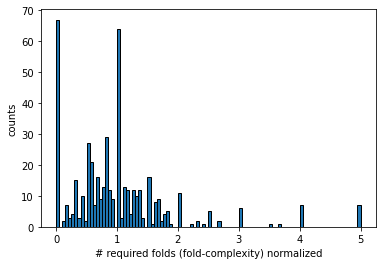

In [210]:
histogram(module2reqFoldsNumnormalized, x_axis='# required folds (fold-complexity) normalized', bins=100)

In [211]:
for key, value in module2reqFoldsNumnormalized.items():
    if value > 3:
        print(f"#folds={round(value,1)} {key}: {modules[key]}")

#folds=5.0 M00072: N-glycosylation by oligosaccharyltransferase
#folds=4.0 M00142: NADH:ubiquinone oxidoreductase, mitochondria
#folds=4.0 M00143: NADH dehydrogenase (ubiquinone) Fe-S protein/flavoprotein complex, mitochondria
#folds=4.0 M00144: NADH:quinone oxidoreductase, prokaryotes
#folds=4.0 M00145: NAD(P)H:quinone oxidoreductase, chloroplasts and cyanobacteria
#folds=4.0 M00146: NADH dehydrogenase (ubiquinone) 1 alpha subcomplex
#folds=4.0 M00147: NADH dehydrogenase (ubiquinone) 1 beta subcomplex
#folds=5.0 M00149: Succinate dehydrogenase, prokaryotes
#folds=5.0 M00150: Fumarate reductase, prokaryotes
#folds=5.0 M00154: Cytochrome c oxidase
#folds=5.0 M00155: Cytochrome c oxidase, prokaryotes
#folds=5.0 M00156: Cytochrome c oxidase, cbb3-type
#folds=3.7 M00174: Methane oxidation, methanotroph, methane => formaldehyde
#folds=5.0 M00595: Thiosulfate oxidation by SOX complex, thiosulfate => sulfate
#folds=4.0 M00624: Terephthalate degradation, terephthalate => 3,4-dihydroxybenzoate


#### with just group1, which modules are do-able?

In [212]:
def fold_complexityG1(module):
    available = set(group1.keys())
    
    for rxn in module2x[module]:
        skip_this_rxn = False
        for rule in rxn:
            if all(x in available for x in rule):  # this rule can be made using group1 folds
                skip_this_rxn = True
                break
        if skip_this_rxn:
            continue
        else:
            if rxn != [{'spontaneous'}]:  # ignore spontaneous
                print(f'{module} is beyond group1 because of rxn:{rxn}')
                return
        
    print(f'{module} is within group1!!!!!!!!!!!!!!!!!!!!!!!')
    return True

In [213]:
testM = {'M00002':[[{'2002'}], [{'2003', '298'}]]}

In [214]:
group1modules = []
for mod in module2x.keys():
    if fold_complexityG1(mod):
        group1modules.append(mod)

M00001 is beyond group1 because of rxn:[{'2484'}]
M00002 is beyond group1 because of rxn:[{'298', '2003'}]
M00003 is beyond group1 because of rxn:[{'7554', '7515'}, {'7515', '304'}, {'7525'}]
M00004 is beyond group1 because of rxn:[{'298', '2003'}]
M00005 is beyond group1 because of rxn:[{'7573'}]
M00006 is beyond group1 because of rxn:[{'298', '2003'}]
M00007 is beyond group1 because of rxn:[{'7522', '7574'}]
M00008 is beyond group1 because of rxn:[{'298', '2003'}]
M00009 is beyond group1 because of rxn:[{'7542', '2487'}, {'7542', '109', '2487'}]
M00010 is beyond group1 because of rxn:[{'7542', '2487'}, {'7542', '109', '2487'}]
M00011 is beyond group1 because of rxn:[{'7522', '7574', '323'}, {'7522', '7574'}]
M00012 is beyond group1 because of rxn:[{'7542', '2487'}, {'7542', '109', '2487'}]
M00013 is beyond group1 because of rxn:[{'4033', '633', '4052'}]
M00014 is beyond group1 because of rxn:[{'129', '2003'}]
M00015 is beyond group1 because of rxn:[{'7524', '7531'}, {'1', '7531'}]
M0

In [215]:
len(group1modules), len(module2x)
# 20% of all KEGG modules can be catalyzed using only Group1 folds (n=37, 37/397 = 9.3%)

(103, 479)

In [216]:
for mod in group1modules:
    print(f'{mod}: {modules[mod]}')

M00021: Cysteine biosynthesis, serine => cysteine
M00023: Tryptophan biosynthesis, chorismate => tryptophan
M00024: Phenylalanine biosynthesis, chorismate => phenylpyruvate => phenylalanine
M00035: Methionine degradation
M00050: Guanine ribonucleotide biosynthesis, IMP => GDP,GTP
M00052: Pyrimidine ribonucleotide biosynthesis, UMP => UDP/UTP,CDP/CTP
M00086: beta-Oxidation, acyl-CoA synthesis
M00091: Phosphatidylcholine (PC) biosynthesis, PE => PC
M00094: Ceramide biosynthesis
M00098: Acylglycerol degradation
M00112: Tocopherol/tocotorienol biosynthesis, homogentisate + phytyl/geranylgeranyl-PP => tocopherol/tocotorienol
M00132: Inositol phosphate metabolism, Ins(1,3,4)P3 => phytate
M00140: C1-unit interconversion, prokaryotes
M00141: C1-unit interconversion, eukaryotes
M00148: Succinate dehydrogenase (ubiquinone)
M00151: Cytochrome bc1 complex respiratory unit
M00152: Cytochrome bc1 complex
M00157: F-type ATPase, prokaryotes and chloroplasts
M00158: F-type ATPase, eukaryotes
M00159: V/

In [217]:
'2484' in group1

False

In [218]:
group1

{'3997': 3332.0,
 '1': 2268.0,
 '4011': 3277.0,
 '253': 3063.0,
 '7574': 3282.0,
 '875': 2855.0,
 '206': 454.0,
 '3016': 2687.0,
 '328': 2853.0,
 '2486': 3173.0,
 '212': 2841.0,
 '148': 3329.0,
 '2002': 155.0,
 '325': 555.0,
 '4952': 457.0,
 '218': 163.0,
 '184': 3069.0,
 '7577': 2684.0,
 '2005': 645.0,
 '2007': 423.0,
 '4953': 457.0,
 '7501': 2247.0,
 '7584': 3275.0,
 '7579': 3299.0,
 '297': 2339.0,
 '2492': 2337.0,
 '7523': 2901.0,
 '101': 3240.0,
 '141': 2951.0,
 '7544': 3069.0,
 '109': 3180.0,
 '2003': 1014.0,
 '2004': 2731.0,
 '602': 457.0,
 '330': 3197.0,
 '304': 2739.0,
 '327': 3269.0}

In [219]:
module2x['M00049']  # 'Adenine ribonucleotide biosynthesis, IMP => ADP,ATP'

[[{'2004'}], [{'4952', '4953', '602'}], [{'2004'}], [{'375'}], [{'304'}]]

In [220]:
# M00049 is beyond group1 because of rxn:[{'375'}]
x2modules['375'], x2names['375'], x2architecture['375']

({'M00049', 'M00974', 'M00975'},
 'Rubredoxin-like',
 'few secondary structure elements')

In [221]:
x2architecture['602'], x2architecture['4952'], x2architecture['4953']

('alpha arrays', 'alpha arrays', 'alpha arrays')

# with just first10, which modules are do-able?

In [222]:
def fold_complexityFirst10(module):
    available = set(first10)
    
    for rxn in module2x[module]:
        skip_this_rxn = False
        for rule in rxn:
            if all(x in available for x in rule):  # this rule can be made using group1 folds
                skip_this_rxn = True
                break
        if skip_this_rxn:
            continue
        else:
            if rxn != [{'spontaneous'}]:  # ignore spontaneous
                print(f'{module} is beyond first10 because of rxn:{rxn}')
                return
        
    print(f'{module} is within first10!!!!!!!!!!!!!!!!!!!!!!!')
    return True

In [223]:
first10modules = []
for mod in module2x.keys():
    if fold_complexityFirst10(mod):
        first10modules.append(mod)

M00001 is beyond first10 because of rxn:[{'2484'}]
M00002 is beyond first10 because of rxn:[{'298', '2003'}]
M00003 is beyond first10 because of rxn:[{'2004'}]
M00004 is beyond first10 because of rxn:[{'298', '2003'}]
M00005 is beyond first10 because of rxn:[{'7573'}]
M00006 is beyond first10 because of rxn:[{'298', '2003'}]
M00007 is beyond first10 because of rxn:[{'7522', '7574'}]
M00008 is beyond first10 because of rxn:[{'298', '2003'}]
M00009 is beyond first10 because of rxn:[{'7542', '2487'}, {'7542', '109', '2487'}]
M00010 is beyond first10 because of rxn:[{'7542', '2487'}, {'7542', '109', '2487'}]
M00011 is beyond first10 because of rxn:[{'7522', '7574', '323'}, {'7522', '7574'}]
M00012 is beyond first10 because of rxn:[{'7542', '2487'}, {'7542', '109', '2487'}]
M00013 is beyond first10 because of rxn:[{'4033', '633', '4052'}]
M00014 is beyond first10 because of rxn:[{'129', '2003'}]
M00015 is beyond first10 because of rxn:[{'7524', '7531'}, {'1', '7531'}]
M00016 is beyond first

M00537 is beyond first10 because of rxn:[{'1', '221', '7514'}]
M00538 is beyond first10 because of rxn:[{'1', '304', '221', '150', '7514', '66'}]
M00539 is beyond first10 because of rxn:[{'243', '4294', '244', '331', '2003', '66'}]
M00540 is beyond first10 because of rxn:[{'7584', '327', '4011'}]
M00541 is beyond first10 because of rxn:[{'2484', '2007'}]
M00542 is within first10!!!!!!!!!!!!!!!!!!!!!!!
M00543 is beyond first10 because of rxn:[{'243', '4294', '244', '331', '2003', '66'}]
M00544 is beyond first10 because of rxn:[{'1', '331', '4294', '221', '66'}]
M00545 is beyond first10 because of rxn:[{'243', '4294', '244', '331', '2003', '66'}]
M00546 is beyond first10 because of rxn:[{'217', '231', '244', '179', '325'}]
M00547 is beyond first10 because of rxn:[{'243', '4294', '244', '331', '2003', '66'}]
M00548 is beyond first10 because of rxn:[{'1', '304', '221', '150', '7514'}]
M00549 is beyond first10 because of rxn:[{'2484'}]
M00550 is beyond first10 because of rxn:[{'3950', '2007

In [224]:
len(first10modules), len(module2x)
# 15% of all KEGG modules can be catalyzed using only first10 folds (n=10, 10/397 = 2.5%)

(74, 479)

In [225]:
for mod in first10modules:
    print(f'{mod}: {modules[mod]}')

M00021: Cysteine biosynthesis, serine => cysteine
M00091: Phosphatidylcholine (PC) biosynthesis, PE => PC
M00132: Inositol phosphate metabolism, Ins(1,3,4)P3 => phytate
M00148: Succinate dehydrogenase (ubiquinone)
M00151: Cytochrome bc1 complex respiratory unit
M00152: Cytochrome bc1 complex
M00163: Photosystem I
M00363: EHEC pathogenicity signature, Shiga toxin
M00415: Fatty acid elongation in endoplasmic reticulum
M00542: EHEC/EPEC pathogenicity signature, T3SS and effectors
M00564: Helicobacter pylori pathogenicity signature, cagA pathogenicity island
M00574: Pertussis pathogenicity signature, pertussis toxin
M00575: Pertussis pathogenicity signature, T1SS
M00576: ETEC pathogenicity signature, heat-labile and heat-stable enterotoxins
M00597: Anoxygenic photosystem II
M00598: Anoxygenic photosystem I
M00611: Oxygenic photosynthesis in plants and cyanobacteria
M00612: Anoxygenic photosynthesis in purple bacteria
M00613: Anoxygenic photosynthesis in green nonsulfur bacteria
M00614: Ano

In [226]:
# which modules did we lose?

In [227]:
lost = set(group1modules) - set(first10modules)
for mod in lost:
    print(f'{mod}: {modules[mod]}')

M00580: Pentose phosphate pathway, archaea, fructose 6P => ribose 5P
M00140: C1-unit interconversion, prokaryotes
M00910: Phenylalanine biosynthesis, chorismate => arogenate => phenylalanine
M00052: Pyrimidine ribonucleotide biosynthesis, UMP => UDP/UTP,CDP/CTP
M00788: Terpentecin biosynthesis, GGAP => terpentecin
M00847: Heme biosynthesis, archaea, siroheme => heme
M00175: Nitrogen fixation, nitrogen => ammonia
M00112: Tocopherol/tocotorienol biosynthesis, homogentisate + phytyl/geranylgeranyl-PP => tocopherol/tocotorienol
M00158: F-type ATPase, eukaryotes
M00157: F-type ATPase, prokaryotes and chloroplasts
M00844: Arginine biosynthesis, ornithine => arginine
M00797: dTDP-D-desosamine biosynthesis
M00933: Plastoquinone biosynthesis, homogentisate + solanesyl-PP => plastoquinol
M00950: Biotin biosynthesis, BioU pathway, pimeloyl-ACP/CoA => biotin
M00170: C4-dicarboxylic acid cycle, phosphoenolpyruvate carboxykinase type
M00338: Cysteine biosynthesis, homocysteine + serine => cysteine
M

# parasitic folds (aux domain)  <=> independent

In [228]:
xgroup397 = set(x2ns.keys())

In [229]:
solo = set()
for rn, rules in rn2rules.items():
    for rule in rules:
        if len(rule) == 1:  # a rule catalyzed by a single fold
            solo.add(next(iter(rule)))

In [230]:
len(solo)

238

In [231]:
aux = xgroup397 - solo

In [232]:
len(aux & set(group1.keys()))

10

In [233]:
for x in aux:
    print(f"X{x}: {x2ns[x]} #rxn={len(x2rxn[x])} {x2names.get(x, 'NO X NAME')}")

X3052: 4315.0 #rxn=8 NO X NAME
X377: 4315.0 #rxn=21 Glucocorticoid receptor-like
X7556: 4315.0 #rxn=6 NO X NAME
X5103: 4315.0 #rxn=1 NO X NAME
X3599: 4281.0 #rxn=2 NO X NAME
X4020: 4315.0 #rxn=28 NO X NAME
X3691: 4315.0 #rxn=6 NO X NAME
X154: 4315.0 #rxn=2 NO X NAME
X3794: 4315.0 #rxn=17 NO X NAME
X177: 4315.0 #rxn=10 NO X NAME
X4045: 4315.0 #rxn=30 NO X NAME
X355: 4315.0 #rxn=19 NO X NAME
X6096: 4315.0 #rxn=1 NO X NAME
X525: 4315.0 #rxn=2 NO X NAME
X279: 4313.0 #rxn=76 NO X NAME
X268: 4305.0 #rxn=20 Sterol carrier protein-like
X3685: 4315.0 #rxn=1 NO X NAME
X106: 4315.0 #rxn=7 NO X NAME
X629: 4315.0 #rxn=4 NO X NAME
X6166: 4308.0 #rxn=7 NO X NAME
X3579: 4315.0 #rxn=3 NO X NAME
X4024: 4315.0 #rxn=9 NO X NAME
X7563: 4315.0 #rxn=3 NO X NAME
X881: 4315.0 #rxn=3 Mog1p/PsbP-like
X3456: 4315.0 #rxn=4 NO X NAME
X277: 4315.0 #rxn=14 NO X NAME
X296: 4314.0 #rxn=20 NO X NAME
X1144: 4315.0 #rxn=2 NO X NAME
X4017: 4315.0 #rxn=10 NO X NAME
X3847: 4315.0 #rxn=3 NO X NAME
X144: 4315.0 #rxn=2 NO X NAM

In [234]:
for x in group1.keys():
    if x in aux:
        print(f"X{x}, {x2ns[x]}, #rxn={len(x2rxn[x])}, {x2names.get(x, 'NO X NAME')}, {x2architecture[x]}")

X3997, 3332.0, #rxn=1, NO X NAME, alpha arrays
X4011, 3277.0, #rxn=139, NO X NAME, beta barrels
X253, 3063.0, #rxn=1, NO X NAME, a+b complex topology
X148, 3329.0, #rxn=10, Histone-like, alpha arrays
X4952, 457.0, #rxn=23, NO X NAME, alpha arrays
X218, 163.0, #rxn=93, Enolase-N/ribosomal protein, a+b two layers
X184, 3069.0, #rxn=21, NO X NAME, alpha arrays
X4953, 457.0, #rxn=15, NO X NAME, alpha arrays
X7544, 3069.0, #rxn=21, NO X NAME, a/b three-layered sandwiches
X602, 457.0, #rxn=25, L-aspartase middle domain-like, alpha arrays


## boxplot

In [235]:
solo2ns = {}
aux2ns = {}
for x in xgroup397:
    if x in solo:
        solo2ns[x] = x2ns[x]
    else:
        aux2ns[x] = x2ns[x]

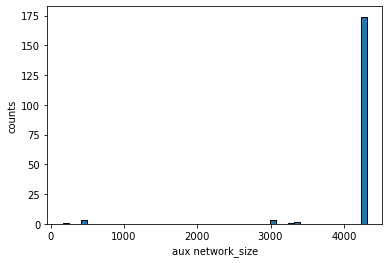

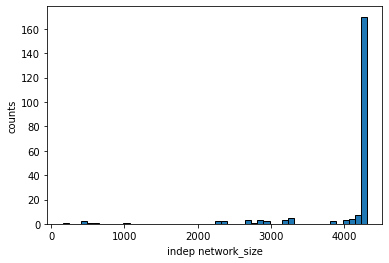

In [236]:
histogram(aux2ns, bins=50, x_axis='aux network_size')
histogram(solo2ns, bins=50, x_axis='indep network_size')

In [237]:
len(solo2ns), len(aux2ns)

(213, 184)

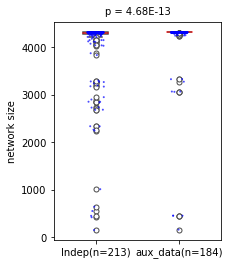

In [238]:
solo_data = np.array(list(solo2ns.values()))
aux_data = np.array(list(aux2ns.values()))

fig, ax = plt.subplots(figsize=(3, 4))

box_colors = ['red', 'blue']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[solo_data, aux_data], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[solo_data, aux_data], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(solo_data, aux_data)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('network size')
ax.set_xticklabels(['Indep(n=213)', 'aux_data(n=184)'])

# plt.savefig('boxplot_ds.png', bbox_inches='tight')
plt.show()

In [239]:
# let's try fold order

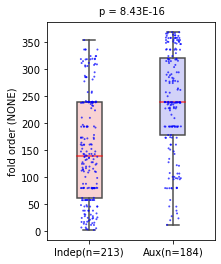

In [240]:
keys, data1, data2 = todata(x2foAveNONE, solo2ns) 
keys, data3, data4 = todata(x2foAveNONE, aux2ns) 
solo_data = np.array(data1)
aux_data = np.array(data3)

fig, ax = plt.subplots(figsize=(3, 4))

box_colors = ['red', 'blue']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[solo_data, aux_data], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[solo_data, aux_data], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(solo_data, aux_data)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('fold order (NONE)')
ax.set_xticklabels(['Indep(n=213)', 'Aux(n=184)'])

plt.savefig('boxplot_foNONE_IndepAux.png', bbox_inches='tight')
plt.show()

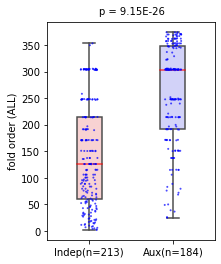

In [241]:
keys, data1, data2 = todata(x2foAveALL, solo2ns) 
keys, data3, data4 = todata(x2foAveALL, aux2ns) 
solo_data = np.array(data1)
aux_data = np.array(data3)

fig, ax = plt.subplots(figsize=(3, 4))

box_colors = ['red', 'blue']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[solo_data, aux_data], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[solo_data, aux_data], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(solo_data, aux_data)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('fold order (ALL)')
ax.set_xticklabels(['Indep(n=213)', 'Aux(n=184)'])

plt.savefig('boxplot_foALL_IndepAux.png', bbox_inches='tight')
plt.show()

In [242]:
# let's try 50% cutoff for fraction of independently catalyzed reactions

In [243]:
x2indepRxnFrac = csv2dict('../data/assets/xgroup2/xgroup2indepRxnFraction.csv')

In [244]:
indepHigh = {}
indepLow = {}
for x, frac in x2indepRxnFrac.items():
    if frac > 0.5:  # high independent
        indepHigh[x] = x2indepRxnFrac[x]
    else:
        indepLow[x] = x2indepRxnFrac[x]

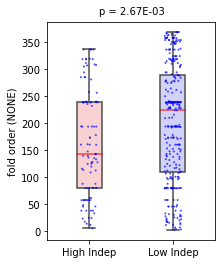

In [245]:
keys, data1, data2 = todata(x2foAveNONE, indepHigh) 
keys, data3, data4 = todata(x2foAveNONE, indepLow) 
solo_data = np.array(data1)
aux_data = np.array(data3)

fig, ax = plt.subplots(figsize=(3, 4))

box_colors = ['red', 'blue']
# Use seaborn boxplot
boxplot = sns.boxplot(data=[solo_data, aux_data], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[solo_data, aux_data], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(solo_data, aux_data)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('fold order (NONE)')
ax.set_xticklabels(['High Indep', 'Low Indep'])

plt.show()

In [246]:
# X4011 is arua for 'M00086': 'beta-Oxidation, acyl-CoA synthesis'

In [247]:
group1parasite2Modules = {}
for x in group1.keys():
    if x in aux:
        group1parasite2Modules[x] = x2modules.get(x, {'NO MODULE'})

In [248]:
for x in group1parasite2Modules:
    for module in group1parasite2Modules[x]:
        print(x, module, modules.get(module, 'no module'))


3997 NO MODULE no module
4011 M00826 C-1027 benzoxazolinate moiety biosynthesis, chorismate => benzoxazolinyl-CoA
4011 M00932 Phylloquinone biosynthesis, chorismate (+ phytyl-PP) => phylloquinol
4011 M00113 Jasmonic acid biosynthesis
4011 M00829 3,6-Dimethylsalicylyl-CoA biosynthesis, malonyl-CoA => 6-methylsalicylate => 3,6-dimethylsalicylyl-CoA
4011 M00376 3-Hydroxypropionate bi-cycle
4011 M00137 Flavanone biosynthesis, phenylalanine => naringenin
4011 M00901 Fumiquinazoline biosynthesis, tryptophan + alanine + anthranilate => fumiquinazoline
4011 M00672 Penicillin biosynthesis, aminoadipate + cycteine + valine => penicillin
4011 M00828 Maduropeptin beta-hydroxy acid moiety biosynthesis, tyrosine => 3-(4-hydroxyphenyl)-3-oxopropanoyl-PCP
4011 M00878 Phenylacetate degradation, phenylaxetate => acetyl-CoA/succinyl-CoA
4011 M00013 Malonate semialdehyde pathway, propanoyl-CoA => acetyl-CoA
4011 M00374 Dicarboxylate-hydroxybutyrate cycle
4011 M00086 beta-Oxidation, acyl-CoA synthesis
4011

In [249]:
arua & set(group1.keys())

{'875'}

In [250]:
aux & set(group1.keys())

{'148', '184', '218', '253', '3997', '4011', '4952', '4953', '602', '7544'}

In [251]:
print(arua & aux)

{'3052', '3001', '4028', '4022', '640', '4048', '4004', '590', '270', '3115', '1055', '199', '6051', '6096', '3688', '4076'}


### domain-only

In [252]:
a_only

{'5103'}

In [253]:
print(sorted(b_only, key=lambda x: int(x)))

['582', '640', '914', '1055', '3018', '3339', '3847', '4035', '4036', '4054', '6051', '6113', '6174']


In [254]:
print(sorted(e_only, key=lambda x: int(x)))

['558', '3257', '3322', '3371', '3777']


In [255]:
b_only & arua

{'1055', '582', '6051', '640'}

In [256]:
print(b_only & aux) # 12 aux, 1 indep (X582)

{'4036', '4035', '3339', '640', '3018', '3847', '6174', '914', '4054', '1055', '6051', '6113'}


In [257]:
getXinfo('582')
for mod in x2modules.get('582', 0):
    print(mod, modules[mod])
for rxn in x2rxn['582']:
    print(rxn, rn2rules[rxn])

X582 |ds_a/b/e= 0.0 0.0 0.0 |fo=238.28 |ns=4315 |#rxn=8 |group2 |indep |Xname=N/A |arua |b_only
M00174 Methane oxidation, methanotroph, methane => formaldehyde
R01146 {frozenset({'582'})}
R09127 {frozenset({'582'})}
R09128 {frozenset({'582'})}
R10713 {frozenset({'582'})}
R09128_v1 {frozenset({'582'})}
R01146_v1 {frozenset({'582'})}
R09127_v1 {frozenset({'582'})}
R10713_v1 {frozenset({'582'})}


In [258]:
for r in x2rxn['582']:
    url = f'https://rest.kegg.jp/get/{r}'
    response = requests.get(url)

    if response.status_code == 200:
        # Print the content of the response
        print(response.text)
        print('---------------------------------')
    else:
        print(f"Error: {response.status_code}")

ENTRY       R01146                      Reaction
NAME        methanol:ferricytochrome-c oxidoreductase;
            methanol dehydrogenase
DEFINITION  Methanol + 2 Ferricytochrome cL <=> Formaldehyde + 2 Ferrocytochrome cL + 2 H+
EQUATION    C00132 + 2 C18233 <=> C00067 + 2 C18234 + 2 C00080
RCLASS      RC00034  C00067_C00132
ENZYME      1.1.2.7         1.1.2.10
PATHWAY     rn00680  Methane metabolism
            rn01100  Metabolic pathways
            rn01120  Microbial metabolism in diverse environments
            rn01200  Carbon metabolism
MODULE      M00174  Methane oxidation, methanotroph, methane => formaldehyde
BRITE       Enzymatic reactions [BR:br08201]
             1. Oxidoreductase reactions
              1.1  Acting on the CH-OH group of donors
               1.1.2  With a cytochrome as acceptor
                1.1.2.7
                 R01146  Methanol + 2 Ferricytochrome cL <=> Formaldehyde + 2 Ferrocytochrome cL + 2 H+
                1.1.2.10
                 R01146  Me